In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import so

## Load the data

In [3]:
df = so.load_data()
so.did_prepare_data(df)
print(df.info())

questions = so.questions(df)
answers = so.answers(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5997763 entries, 0 to 5997762
Data columns (total 20 columns):
 #   Column            Dtype         
---  ------            -----         
 0   PostTypeId        int64         
 1   AcceptedAnswerId  float64       
 2   CreationDate      datetime64[ns]
 3   Score             int64         
 4   ViewCount         float64       
 5   AnswerCount       float64       
 6   CommentCount      int64         
 7   FavoriteCount     float64       
 8   OwnerUserId       float64       
 9   Title             object        
 10  Tags              object        
 11  line_count        float64       
 12  T                 int64         
 13  P                 int64         
 14  W                 int64         
 15  code              object        
 16  text              object        
 17  log_lc            float64       
 18  D                 int32         
 19  date              datetime64[ns]
dtypes: datetime64[ns](2), float64(7), int32(1), in

In [4]:
# Tags
filenames = ['java_c.csv', 'python_c.csv', 'web_c.csv']
tags = ['java', 'python', 'web']

tag_dfs = {}
for tag, filename in zip(tags, filenames):
        print(f'Loading: {tag}')
        tag_df = so.load_data(f'data/csv/tags/{filename}')
        so.did_prepare_data(tag_df, 'tags')
        tag_dfs[tag] = tag_df

Loading: java
Loading: python
Loading: web


### Propensity score

In [5]:
def propensity_scores(data, features):
    formula = 'T ~ ' + ' + '.join(s if s == 'sc_pre' else f'log_{s}' for s in features)
    print(formula)

    logit = smf.logit(formula, data=data).fit()
    data = data.copy()
    data['ps'] = logit.predict(data)

    # Weights
    #data['w_user'] = np.where(data['T'] == 1, 1.0, data['ps'] / (1.0 - data['ps']))
    data['w_user'] = np.where(data['T'] == 1, 1.0 / data['ps'],  1.0 / (1.0 - data['ps']))

    # Trim extreme control weights
    cap = data.loc[data['T'] == 0, 'w_user'].quantile(0.99)
    data.loc[(data['T'] == 0) & (data['w_user'] > cap), 'w_user'] = cap

    # Trim extreme treated weights
    cap = data.loc[data['T'] == 1, 'w_user'].quantile(0.01)
    data.loc[(data['T'] == 1) & (data['w_user'] < cap), 'w_user'] = cap


    return data

In [6]:
def overlap(data):
    # Unweighted treated vs control KDE
    plt.figure()
    sns.kdeplot(data=data, x='ps', hue='T', common_norm=False)
    plt.title('Propensity score KDE (unweighted)')
    plt.xlabel('Propensity score')
    plt.show()
    plt.close()

    # Weighted control KDE vs treated KDE
    plt.figure()
    sns.kdeplot(data=data[data['T']==1], x='ps', label='Treated', common_norm=False)
    sns.kdeplot(data=data[data['T']==0], x='ps', weights='w_user', label='Control weighted', common_norm=False)
    plt.title('Propensity score KDE (weighted)')
    plt.xlabel('Propensity score')
    plt.show()
    plt.close()

### Standardized mean difference

In [7]:
def wmean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    return np.sum(w * x) / np.sum(w)

def wvar(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    mu = wmean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd(df_user, xcol, treat_col="T", wcol=None):
    """
    Balance: treated unweighted, controls weighted by w_user.
    """
    t = df_user[treat_col] == 1
    c = ~t

    x_t = df_user.loc[t, xcol].to_numpy()
    x_c = df_user.loc[c, xcol].to_numpy()

    # Treated weights are 1
    if wcol is not None:
        w_c = df_user.loc[c, wcol].to_numpy()

    mt = x_t.mean()
    if wcol is not None:
        mc = wmean(x_c, w_c)
    else:
        mc = x_c.mean()

    vt = x_t.var(ddof=0)
    if wcol is not None:
        vc = wvar(x_c, w_c)
    else:
        vc = x_c.var(ddof=0)

    denom = np.sqrt((vt + vc) / 2.0)
    return (mt - mc) / denom if denom > 0 else np.nan

## Match and fit

In [8]:
def clean(data):
    data = data.dropna(subset=['OwnerUserId']).copy()
    data['OwnerUserId'] = data['OwnerUserId'].astype(int)
    return data

In [9]:
def regression(data, outcome):
    start_dates, masks = so.rolling_window_masks(data, data_column='date', normalized=True, window_days=30)    

    X, y = so.did_design_matrix(f'{outcome}_bar', data)
    res = so.did_wls(data, X, y, masks, start_dates, outcome)
    return res

Processing: questions
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.669214
         Iterations 6


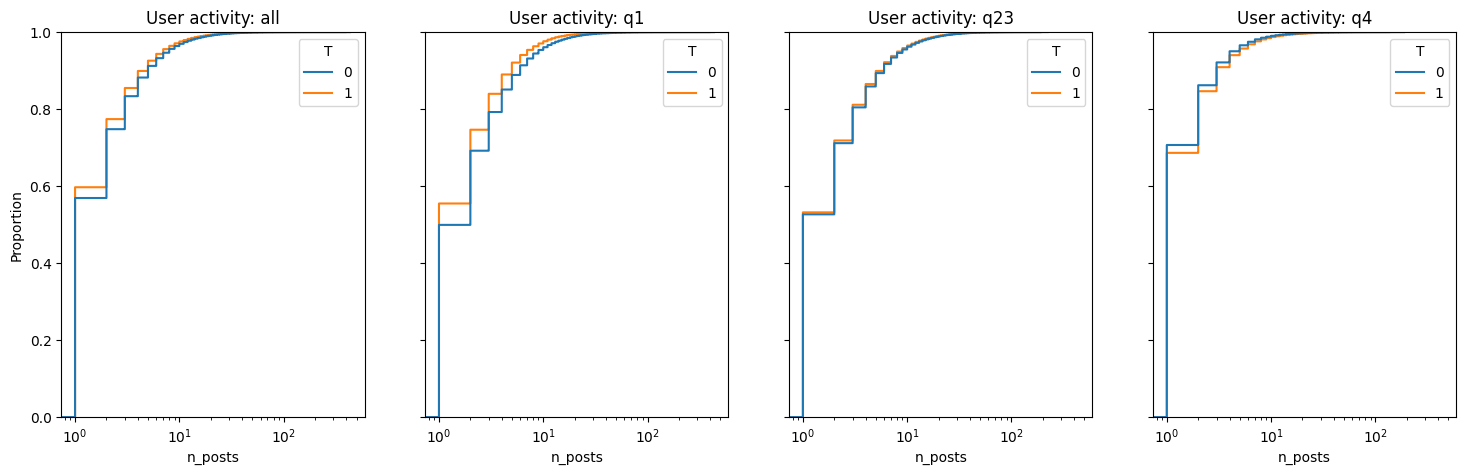

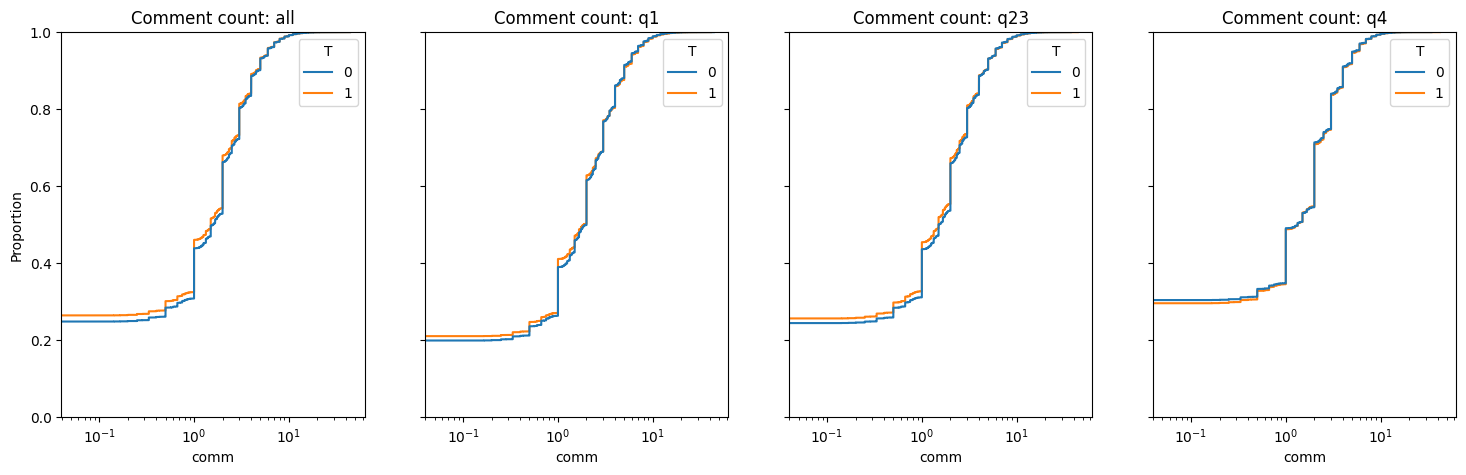

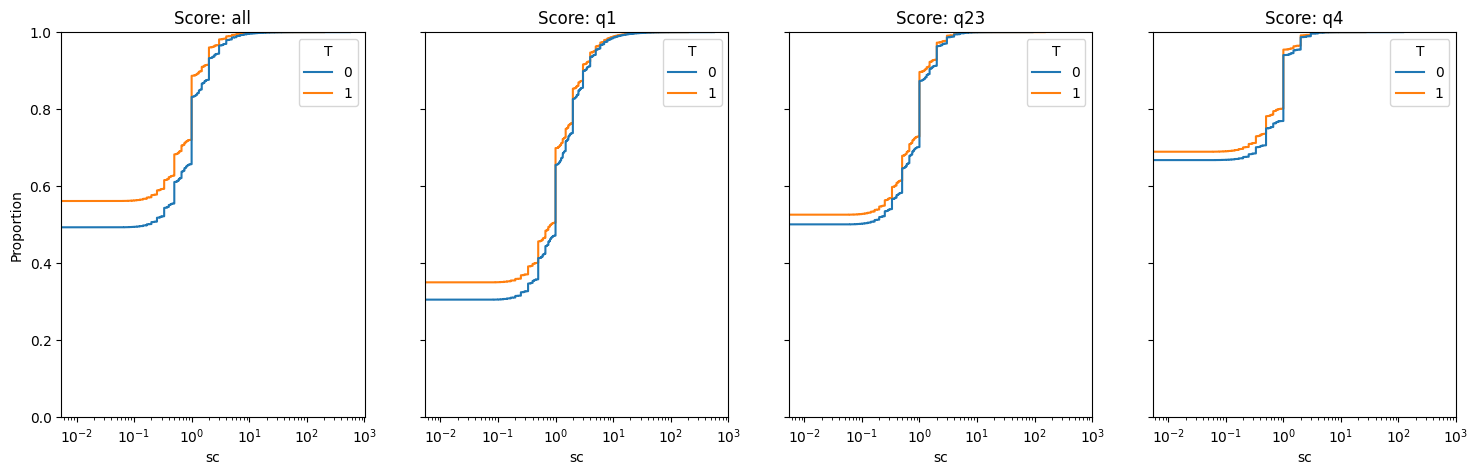

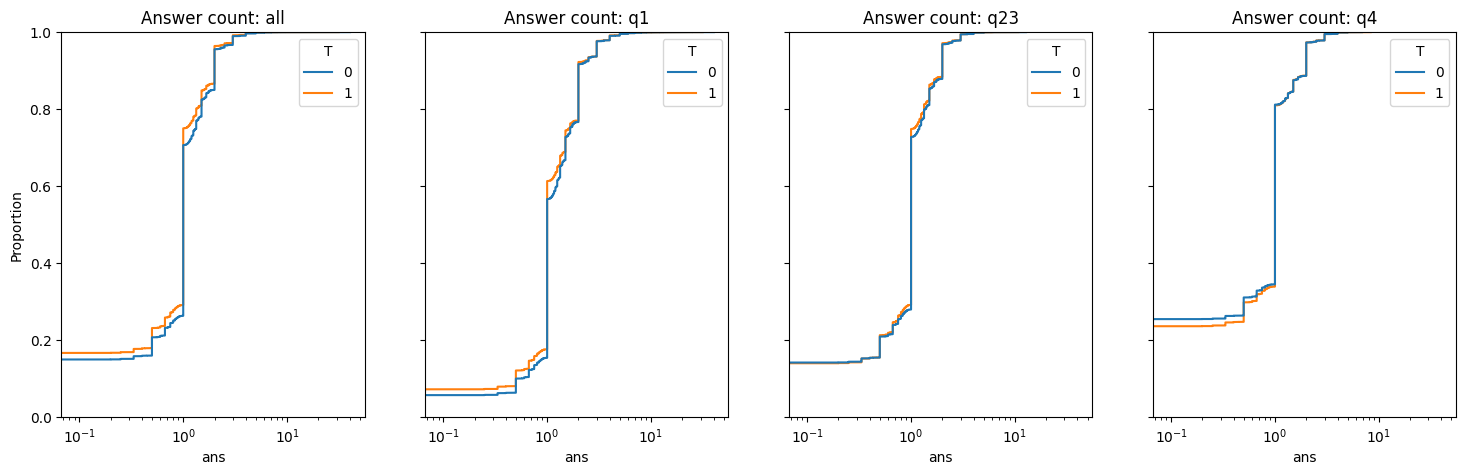

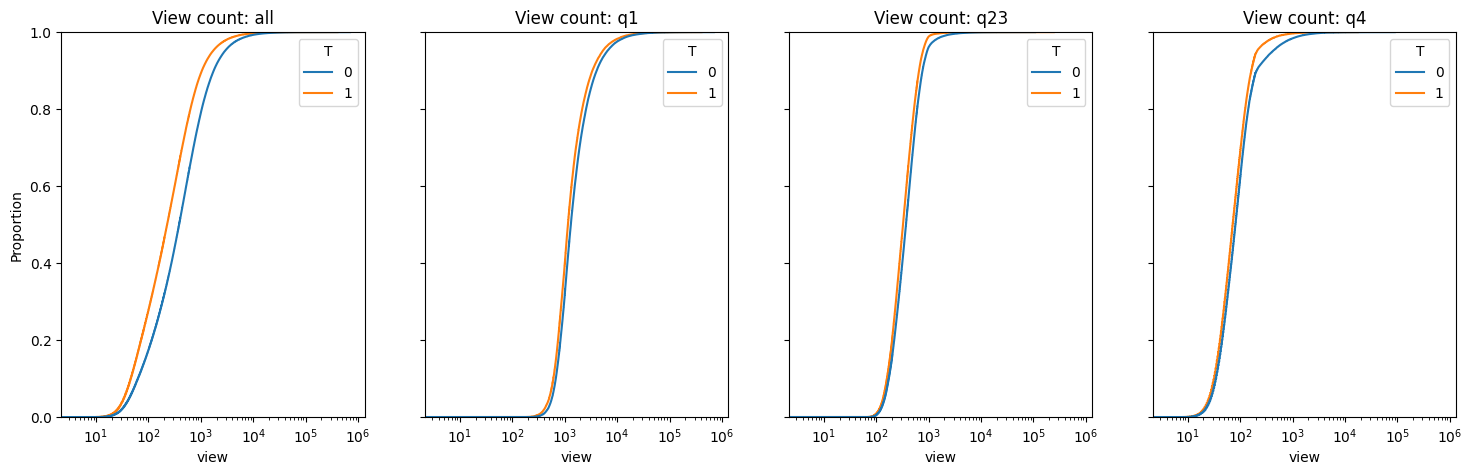

****************************************************************
all
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.05099336655987148
After matching:  act_pre -0.02394375308700992
Balance: --------------
***********
Before matching:  comm_pre -0.06559268450634763
After matching:  comm_pre -0.036817372639830426
Balance: --------------
***********
Before matching:  ans_pre -0.07061980103119883
After matching:  ans_pre -0.03935683469849705
Balance: --------------
***********
Before matching:  view_pre -0.176747044830564
After matching:  view_pre -0.12667341343780208
Balance: --------------
***********
Before matching:  sc_pre -0.12097008728306989
After matching:  sc_pre -0.07843496284696376
Overlap: --------------
      count      mean       std           min        1%        5%       10%  \
T                                                                             
0  997026.0  0.445099  0.101895  1.501

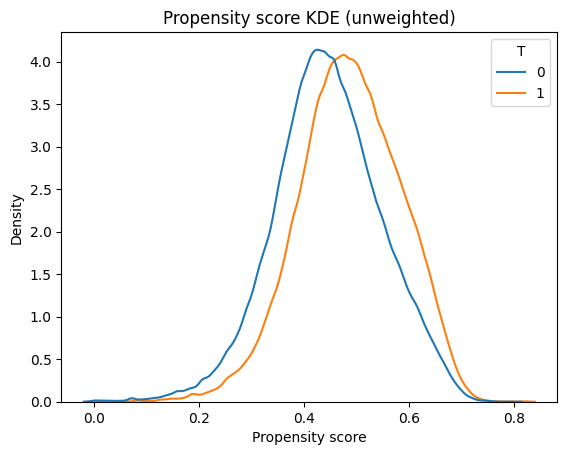

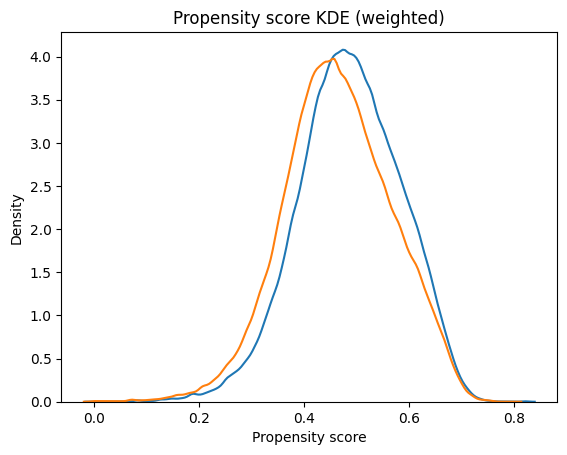

Processing: log_lc


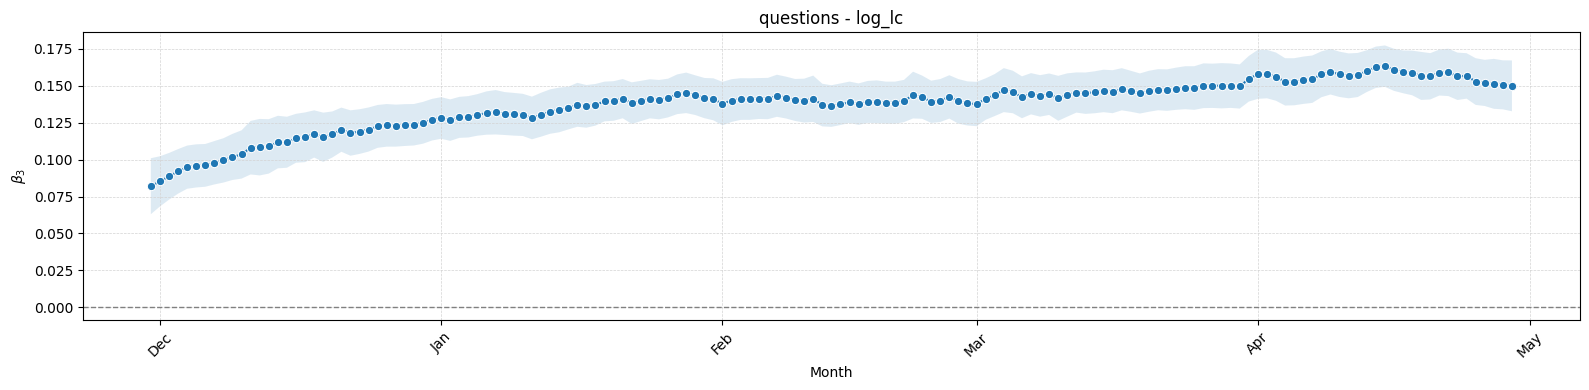

****************************************************************
q1
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.11247063908983056
After matching:  act_pre -0.10341175989527325
Balance: --------------
***********
Before matching:  comm_pre -0.12976667257180835
After matching:  comm_pre -0.12180746600769514
Balance: --------------
***********
Before matching:  ans_pre -0.1138058522708084
After matching:  ans_pre -0.10200650063172706
Balance: --------------
***********
Before matching:  view_pre -0.17950471456174769
After matching:  view_pre -0.1549304704778498
Balance: --------------
***********
Before matching:  sc_pre -0.11099885357538194
After matching:  sc_pre -0.0851337230494918
Overlap: --------------
      count      mean       std           min        1%        5%       10%  \
T                                                                             
0  315410.0  0.332076  0.059264  1.501027

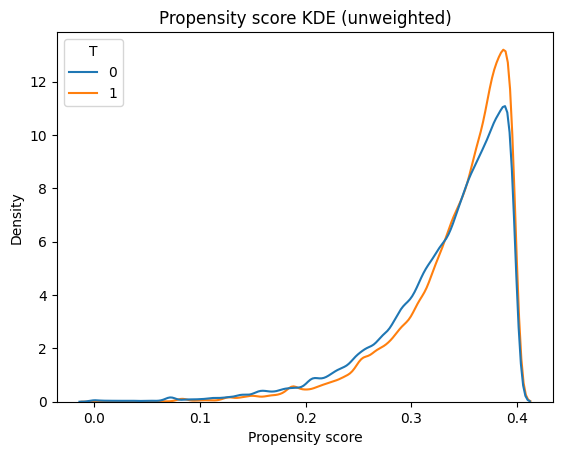

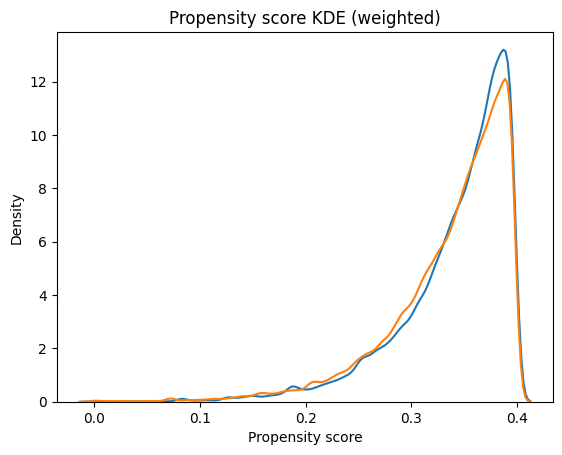

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]


Processing: log_lc


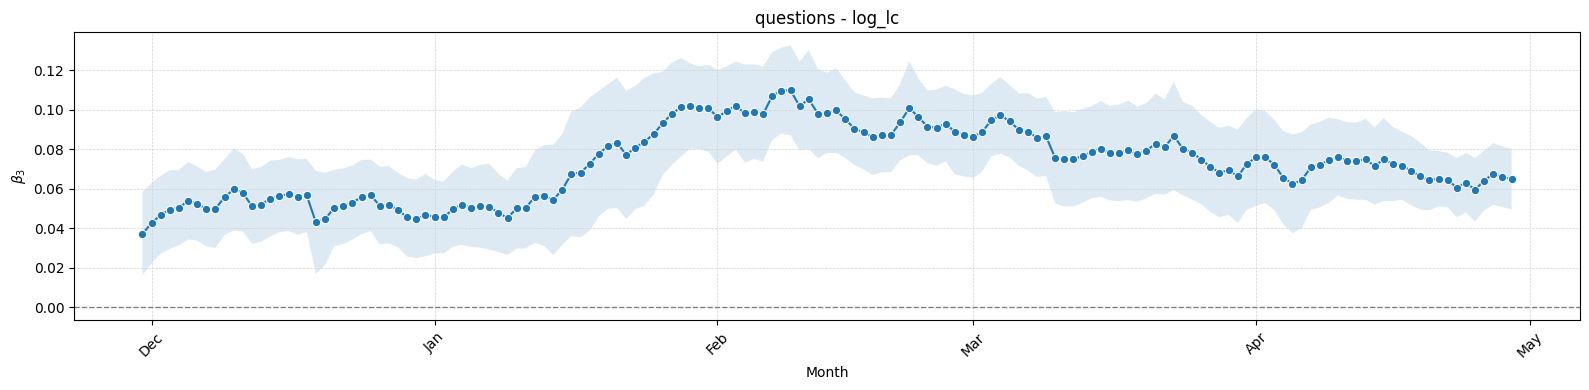

****************************************************************
q23
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.007392679573063998
After matching:  act_pre -0.0057657957340001495
Balance: --------------
***********
Before matching:  comm_pre -0.0007589721272457146
After matching:  comm_pre 0.0016381068451318094
Balance: --------------
***********
Before matching:  ans_pre -0.03352828479403098
After matching:  ans_pre -0.031418908471436864
Balance: --------------
***********
Before matching:  view_pre -0.05962543887090157
After matching:  view_pre -0.047737548619439026
Balance: --------------
***********
Before matching:  sc_pre -0.021547198014307798
After matching:  sc_pre -0.012247653768372708
Overlap: --------------
      count      mean       std       min        1%        5%       10%  \
T                                                                         
0  491928.0  0.461279  0.037886  0.

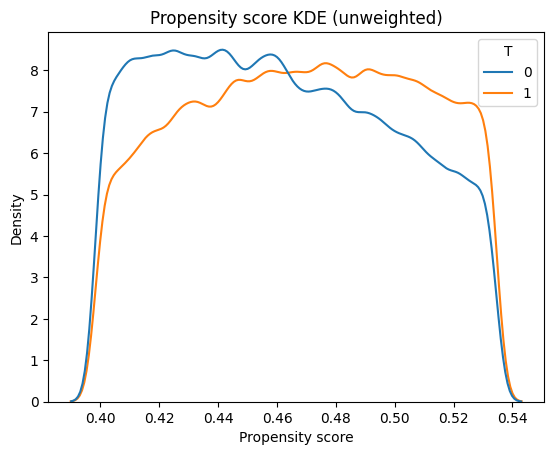

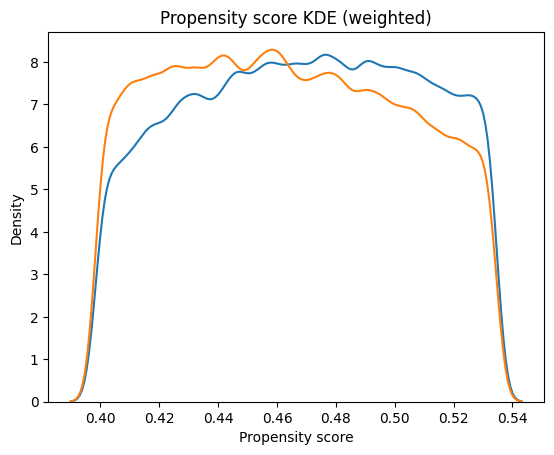

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]


Processing: log_lc


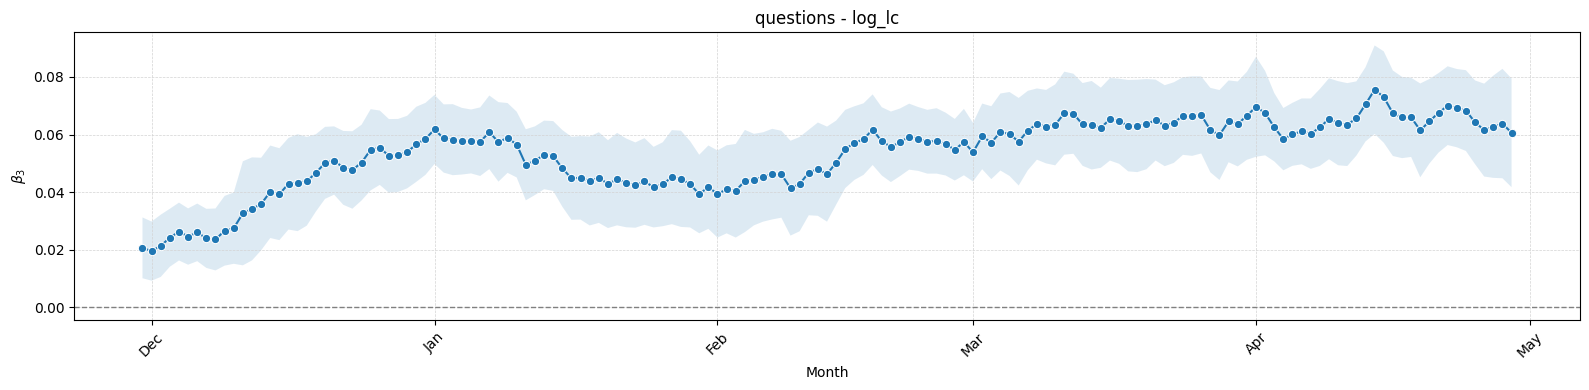

****************************************************************
q4
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.09693818826984336
After matching:  act_pre 0.11101992484262102
Balance: --------------
***********
Before matching:  comm_pre 0.05448255330047224
After matching:  comm_pre 0.0691785899591042
Balance: --------------
***********
Before matching:  ans_pre 0.10218942138212574
After matching:  ans_pre 0.1158054449314681
Balance: --------------
***********
Before matching:  view_pre 0.03711513158356776
After matching:  view_pre 0.052736373305198134
Balance: --------------
***********
Before matching:  sc_pre 0.05374785338045117
After matching:  sc_pre 0.0672164673544309
Overlap: --------------
      count      mean       std       min        1%        5%       10%  \
T                                                                         
0  189688.0  0.591073  0.042215  0.534660  0.535480  0.538

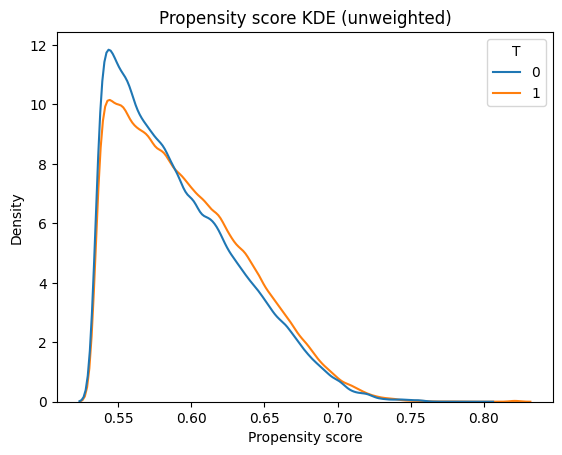

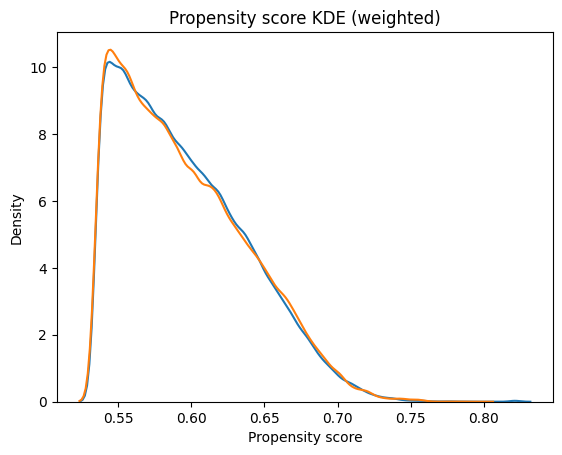

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]


Processing: log_lc


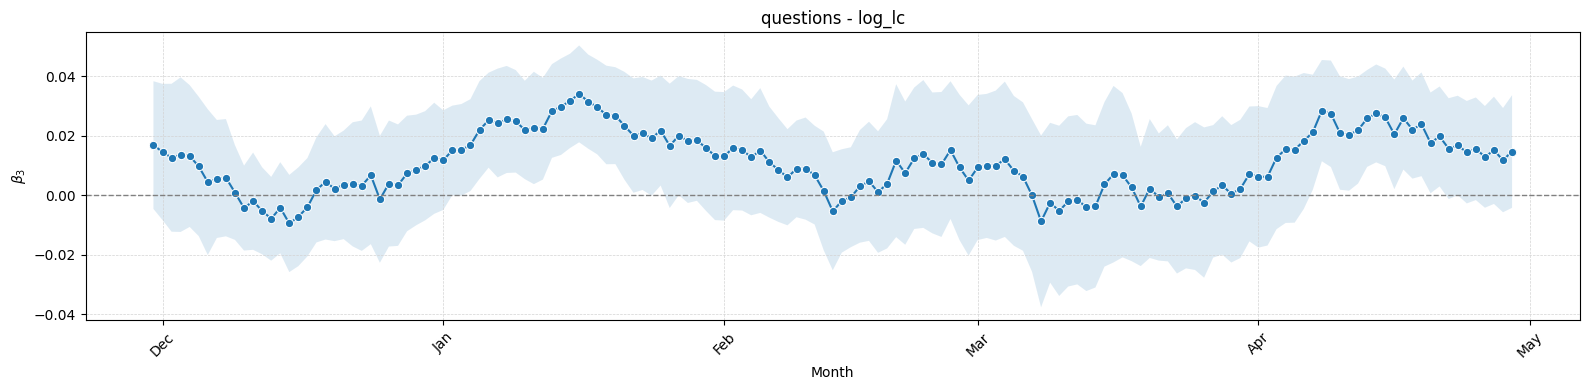

Processing: answers
T ~ log_act_pre + log_comm_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.684313
         Iterations 5


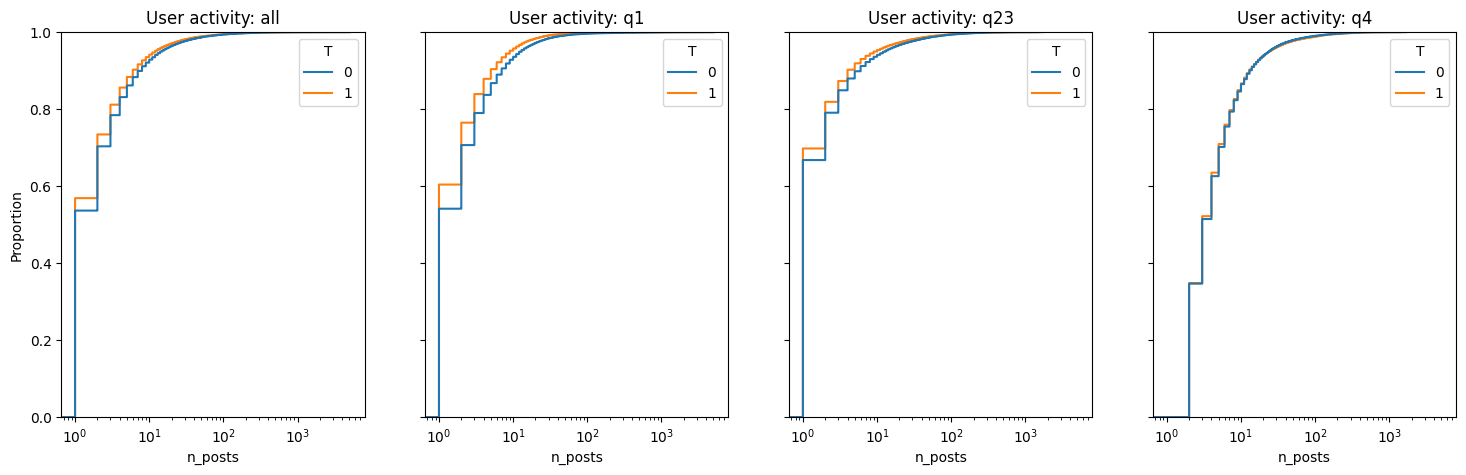

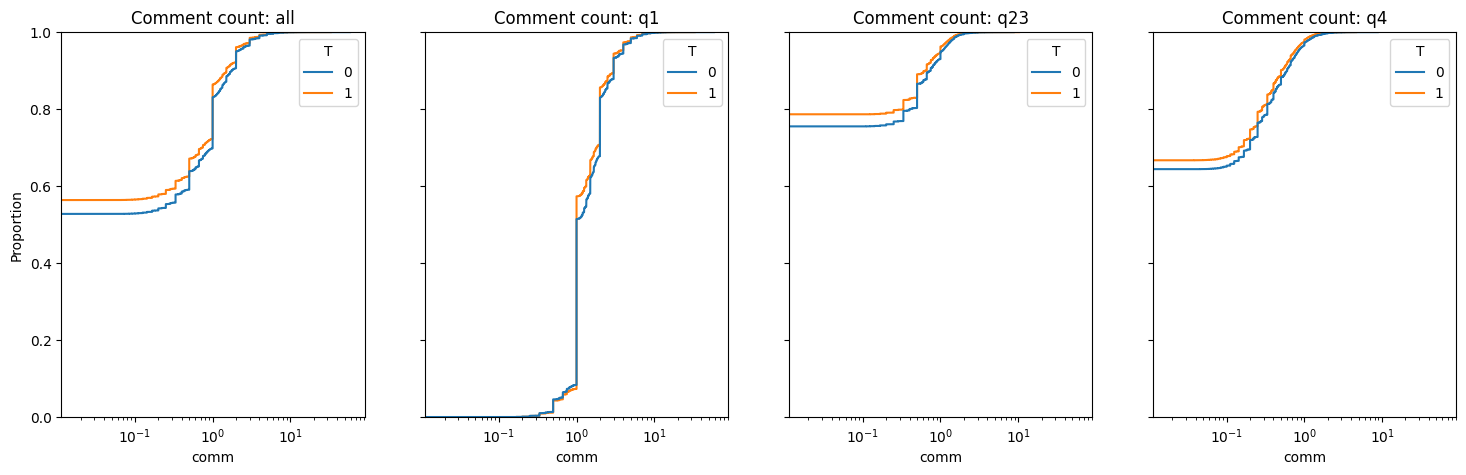

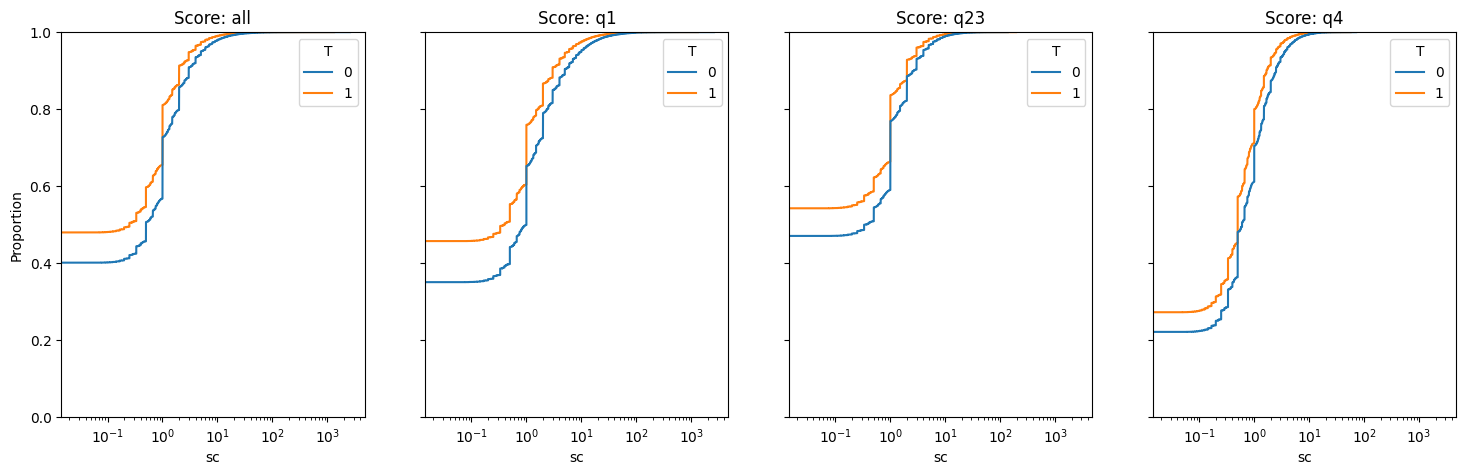

****************************************************************
all
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.07389468227630674
After matching:  act_pre -0.024066429063619603
Balance: --------------
***********
Before matching:  comm_pre -0.1062233707698399
After matching:  comm_pre -0.05410129928836799
Balance: --------------
***********
Before matching:  sc_pre -0.13275263737705004
After matching:  sc_pre -0.080237168204336
Overlap: --------------
       count      mean       std       min        1%        5%       10%  \
T                                                                          
0  1456888.0  0.454449  0.054132  0.077746  0.280741  0.371172  0.397962   
1  1238188.0  0.465282  0.047841  0.150418  0.332089  0.393225  0.414915   

        50%       90%       95%       99%       max  
T                                                    
0  0.462471  0.504754  0.529210  0.577464  0

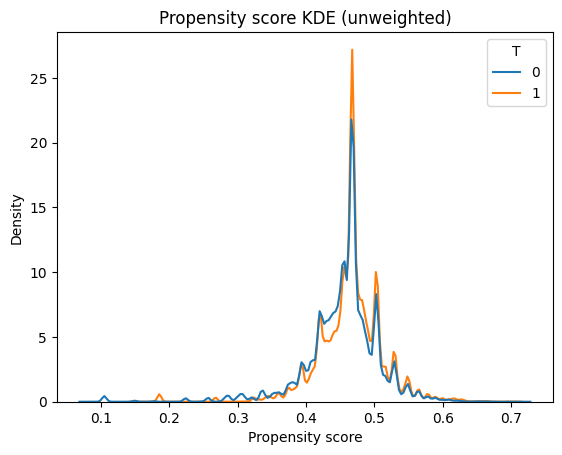

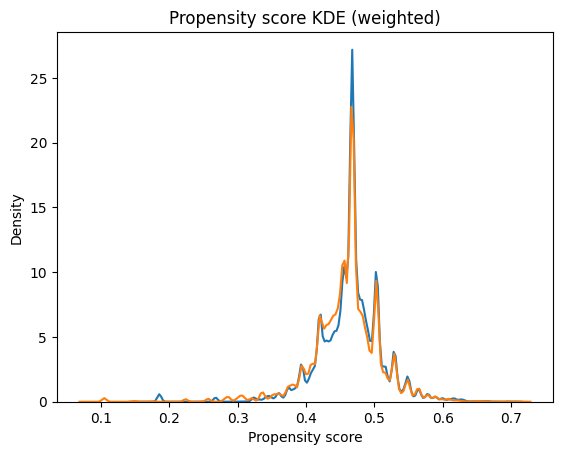

Processing: log_lc


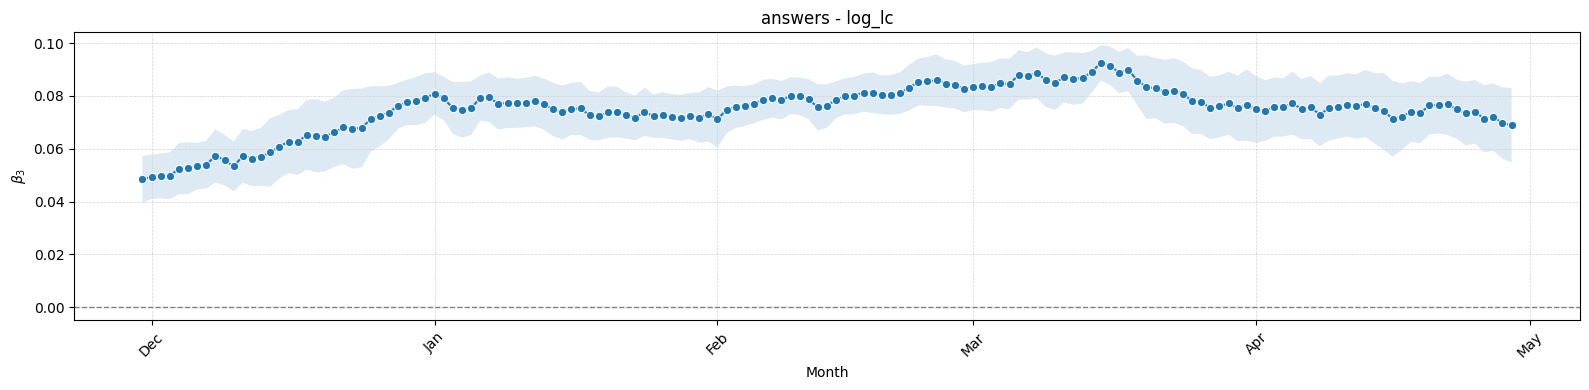

****************************************************************
q1
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.11880480622250307
After matching:  act_pre -0.060992766079985
Balance: --------------
***********
Before matching:  comm_pre -0.1560841353139784
After matching:  comm_pre -0.09936688697182992
Balance: --------------
***********
Before matching:  sc_pre -0.17210596166811976
After matching:  sc_pre -0.11077702203844325
Overlap: --------------
      count      mean       std       min        1%        5%       10%  \
T                                                                         
0  410059.0  0.393750  0.053546  0.077746  0.104573  0.287777  0.334908   
1  263750.0  0.402001  0.041921  0.150418  0.185263  0.338211  0.360479   

        50%       90%       95%       99%       max  
T                                                    
0  0.412749  0.431889  0.434040  0.435970  0.43644

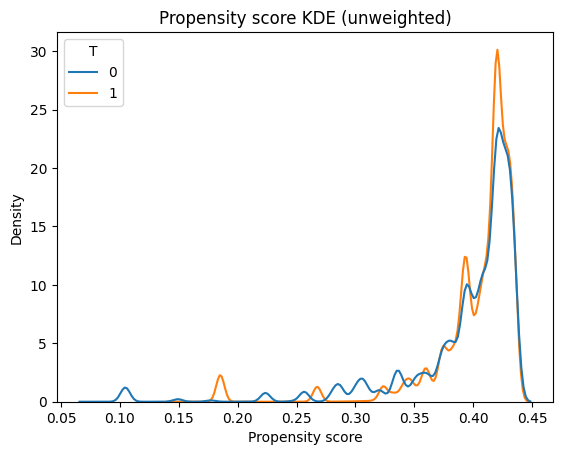

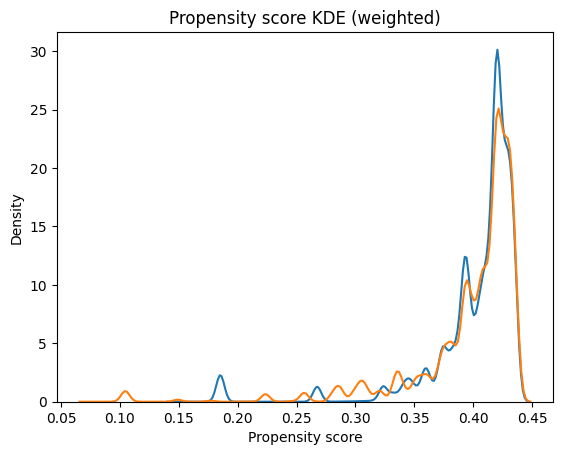

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]


Processing: log_lc


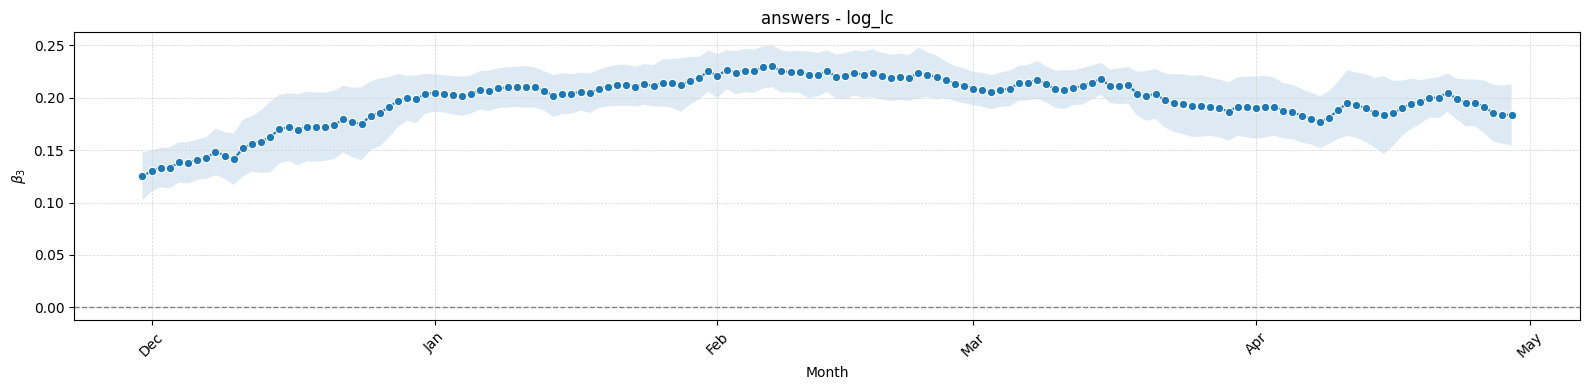

****************************************************************
q23
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.06535878029247869
After matching:  act_pre 0.069692926635143
Balance: --------------
***********
Before matching:  comm_pre 0.04304474309236315
After matching:  comm_pre 0.04860685882468183
Balance: --------------
***********
Before matching:  sc_pre -0.023752388829135152
After matching:  sc_pre -0.017819443152464913
Overlap: --------------
      count      mean       std       min        1%        5%       10%  \
T                                                                         
0  721692.0  0.461634  0.011842  0.436458  0.437265  0.439780  0.443716   
1  625829.0  0.463452  0.011260  0.436447  0.437746  0.441183  0.446075   

        50%       90%       95%       99%       max  
T                                                    
0  0.466476  0.476693  0.480871  0.483315  0.48408

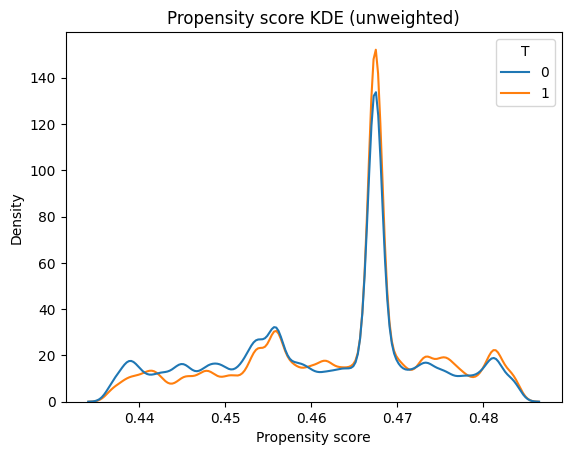

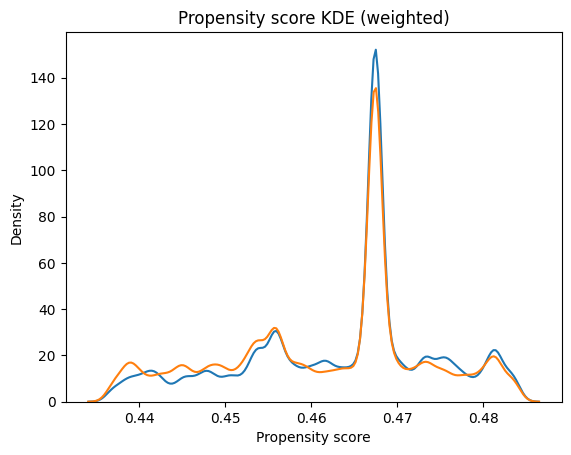

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]


Processing: log_lc


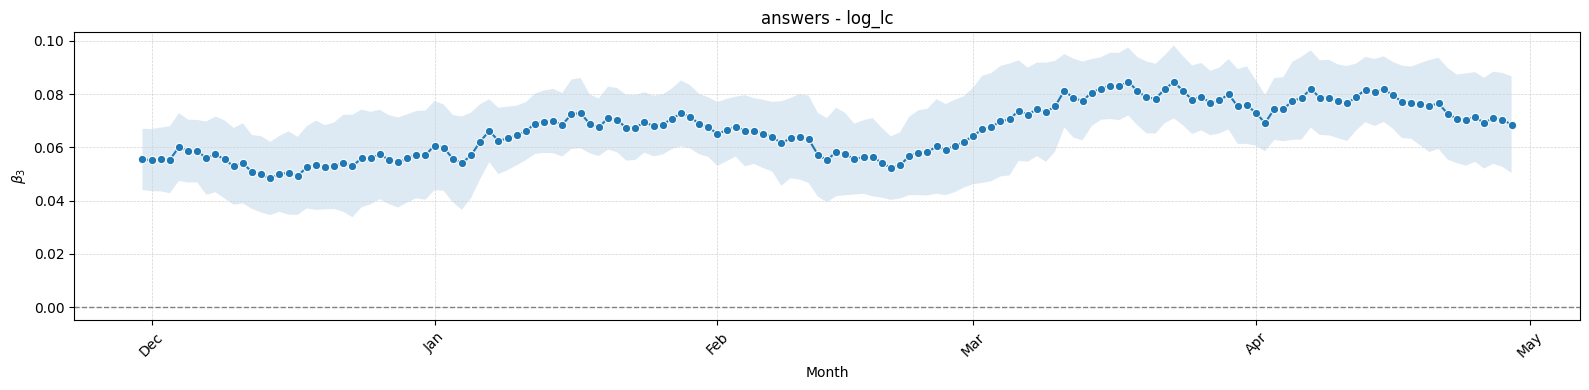

****************************************************************
q4
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.11859519160799918
After matching:  act_pre 0.12792283920312603
Balance: --------------
***********
Before matching:  comm_pre 0.134723342292901
After matching:  comm_pre 0.14744248872889376
Balance: --------------
***********
Before matching:  sc_pre 0.03761124569688657
After matching:  sc_pre 0.049111909067489544
Overlap: --------------
      count      mean       std       min        1%        5%       10%  \
T                                                                         
0  325137.0  0.515053  0.027722  0.484091  0.484700  0.486398  0.488676   
1  348609.0  0.516444  0.030309  0.484095  0.484545  0.486192  0.488788   

        50%       90%       95%       99%       max  
T                                                    
0  0.503661  0.549525  0.571038  0.609650  0.718839  


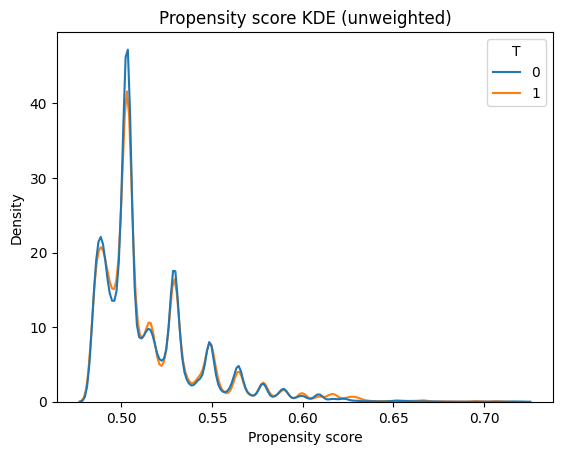

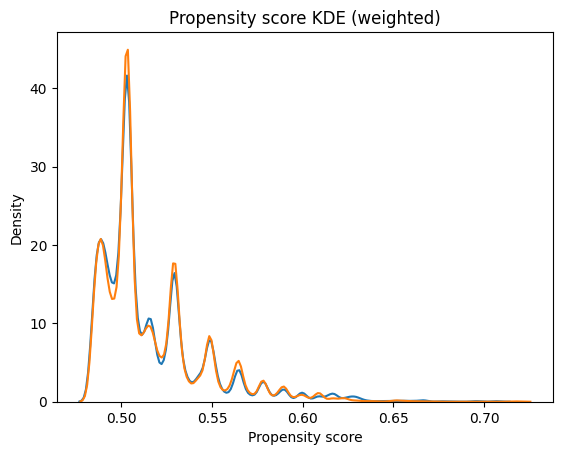

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]


Processing: log_lc


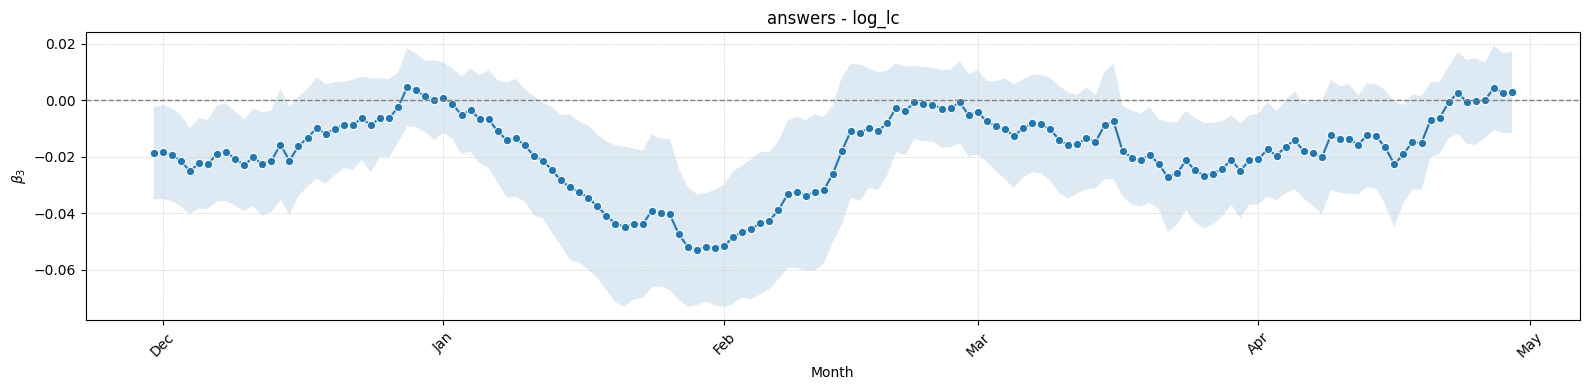

Processing: java
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.670560
         Iterations 6


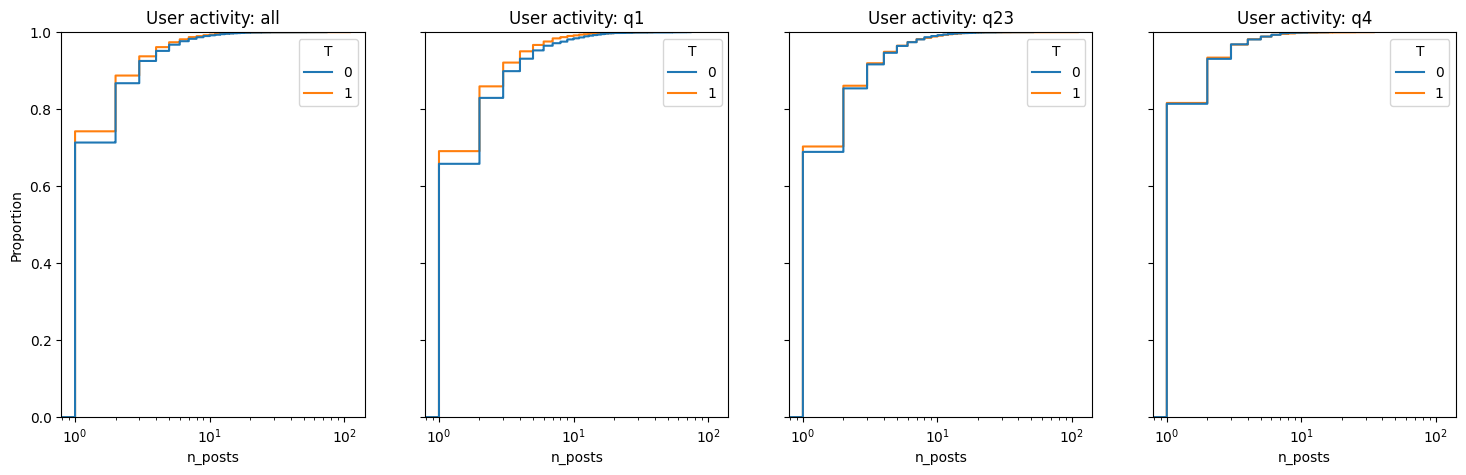

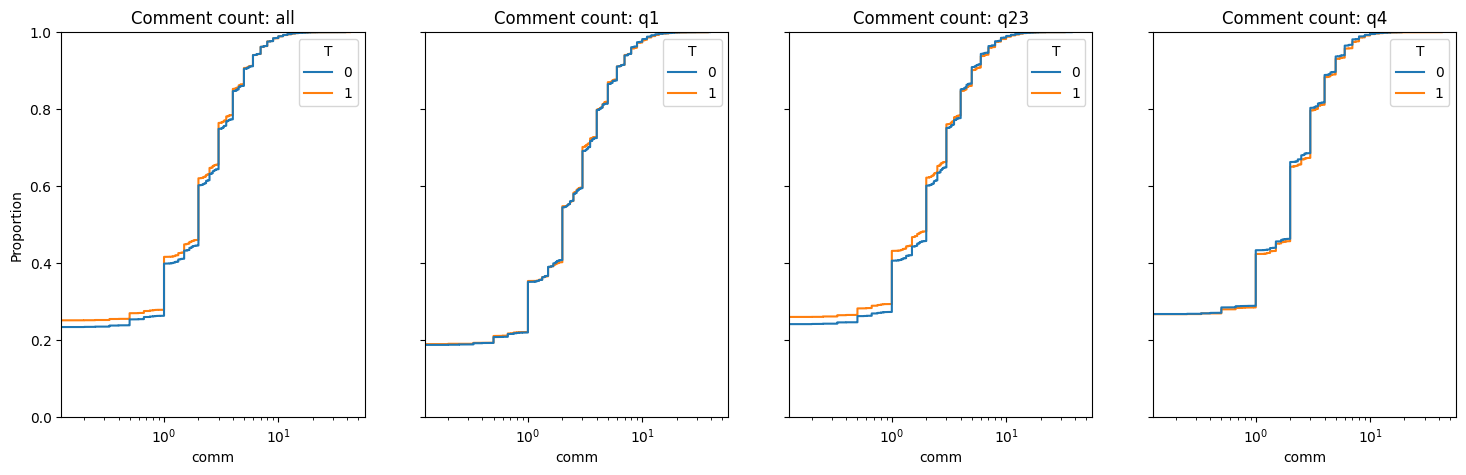

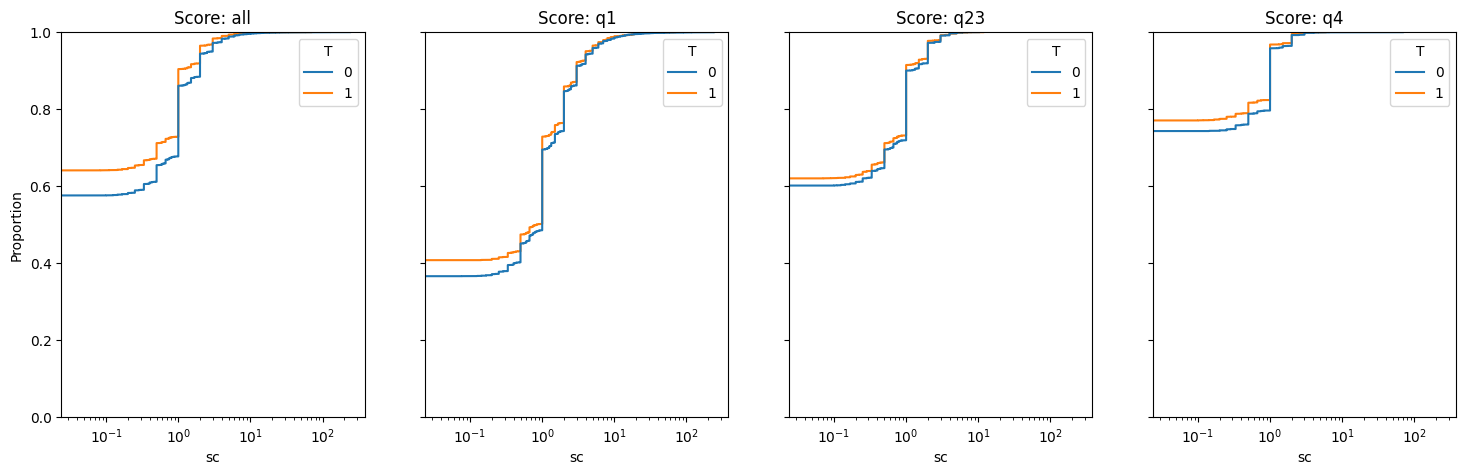

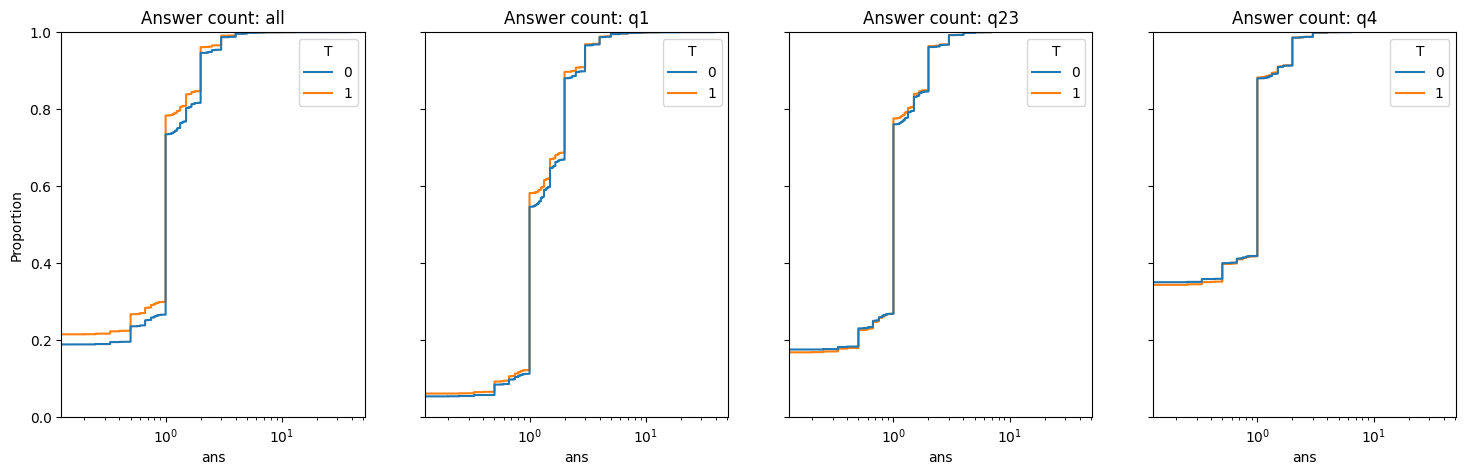

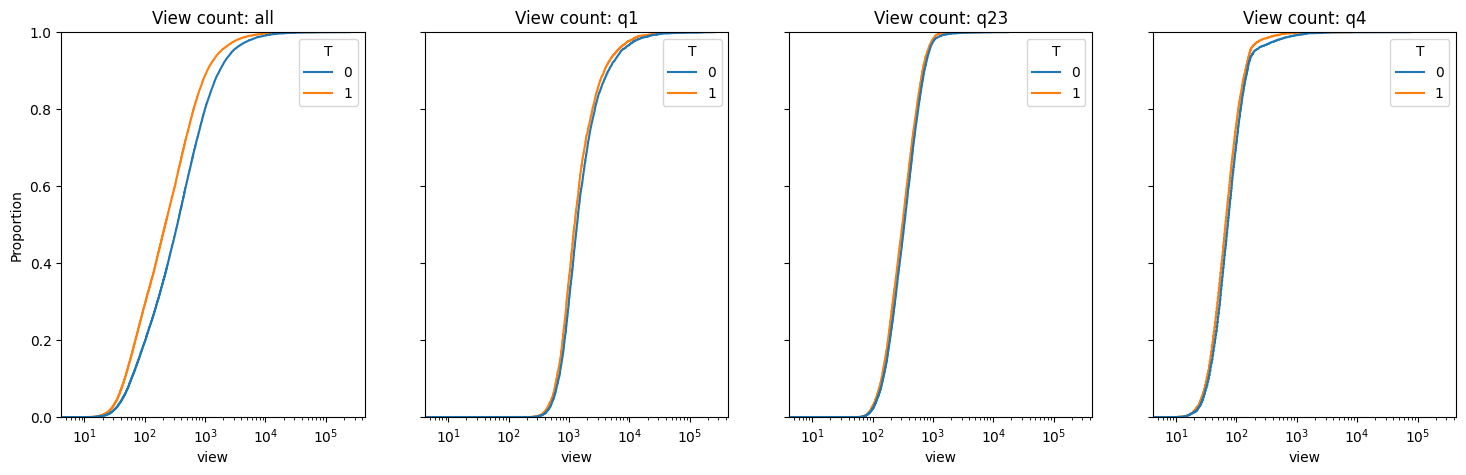

****************************************************************
all
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.04679208868959764
After matching:  act_pre -0.013558478787945047
Balance: --------------
***********
Before matching:  comm_pre -0.03784018816045439
After matching:  comm_pre -0.004154894744597473
Balance: --------------
***********
Before matching:  ans_pre -0.09081484809316039
After matching:  ans_pre -0.04733116601005971
Balance: --------------
***********
Before matching:  view_pre -0.1637629868897701
After matching:  view_pre -0.11597488069284657
Balance: --------------
***********
Before matching:  sc_pre -0.1315480368207499
After matching:  sc_pre -0.08911634217977318
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0  46878.0  0.424724  0.084955  0.000773  0.215

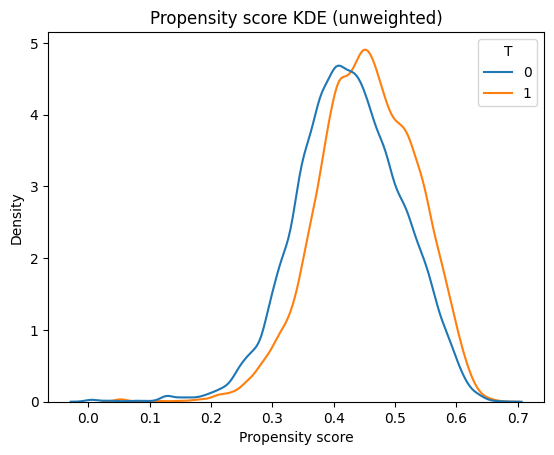

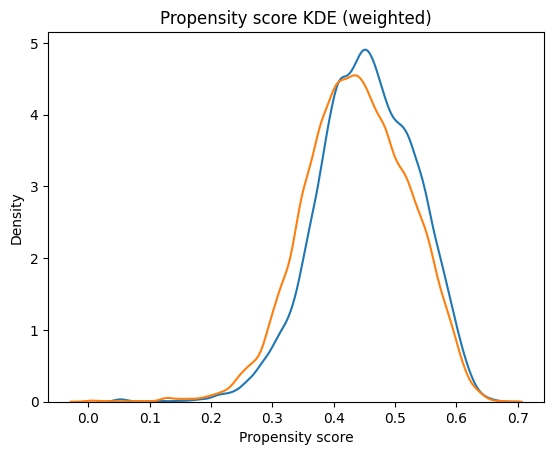

Processing: log_lc


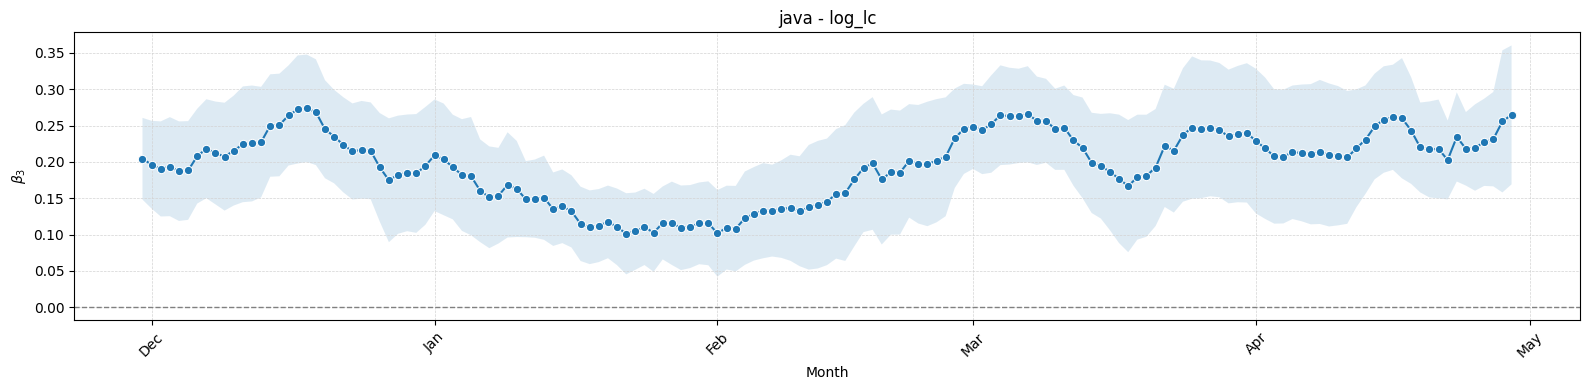

Processing: log_loc


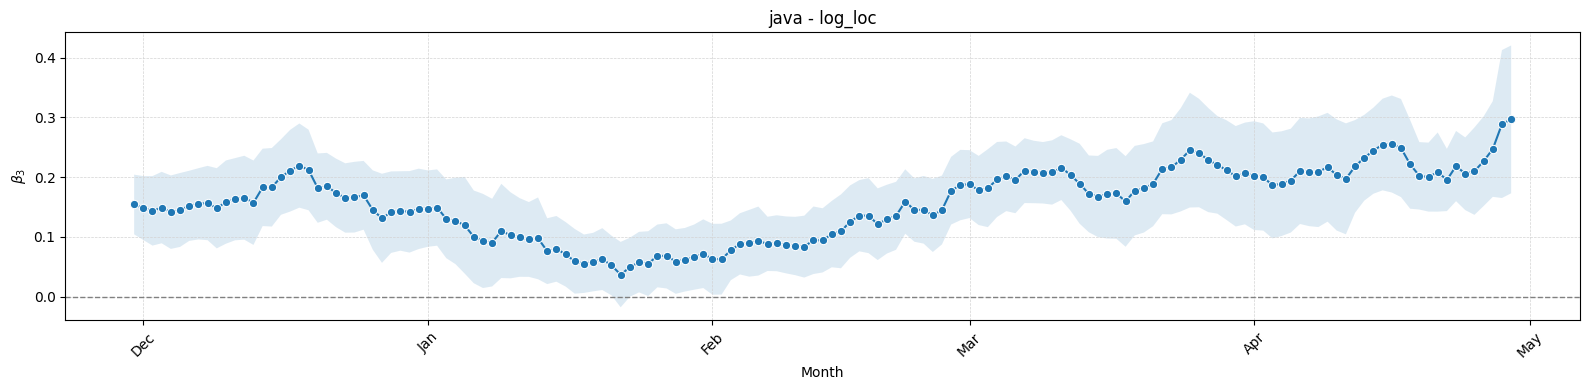

Processing: Medium


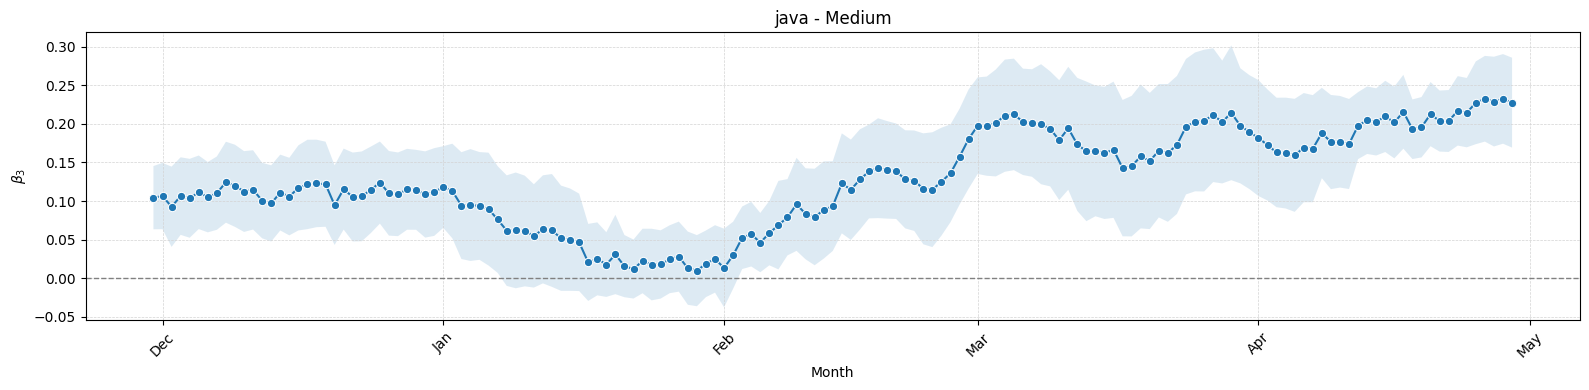

****************************************************************
q1
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.22209710270783653
After matching:  act_pre -0.2105383910972481
Balance: --------------
***********
Before matching:  comm_pre -0.20233359668551945
After matching:  comm_pre -0.19066720706044488
Balance: --------------
***********
Before matching:  ans_pre -0.20382003629444856
After matching:  ans_pre -0.18683842648957355
Balance: --------------
***********
Before matching:  view_pre -0.23805821451319228
After matching:  view_pre -0.20973322161728383
Balance: --------------
***********
Before matching:  sc_pre -0.11630991849737168
After matching:  sc_pre -0.08584634213207355
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0  14418.0  0.328226  0.050459  0.000773  0.12677

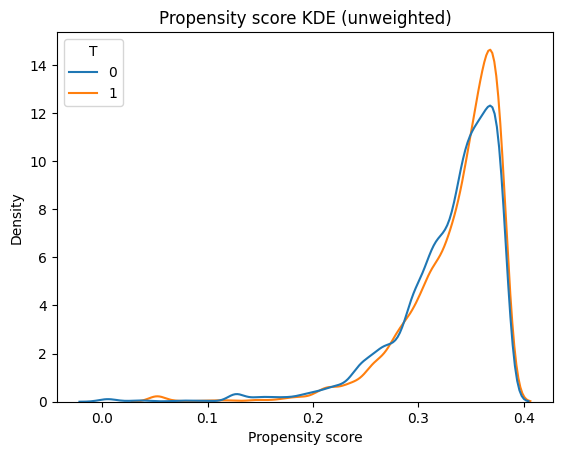

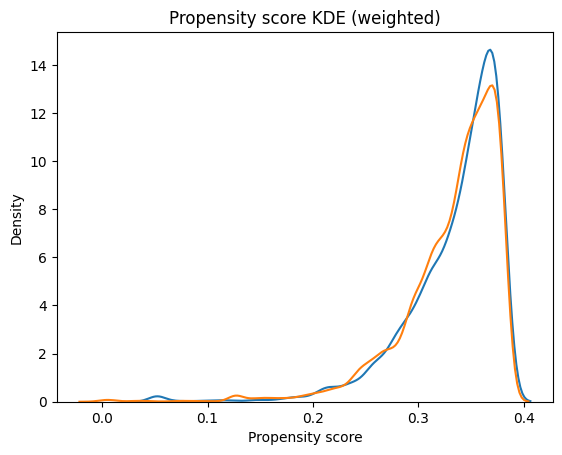

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


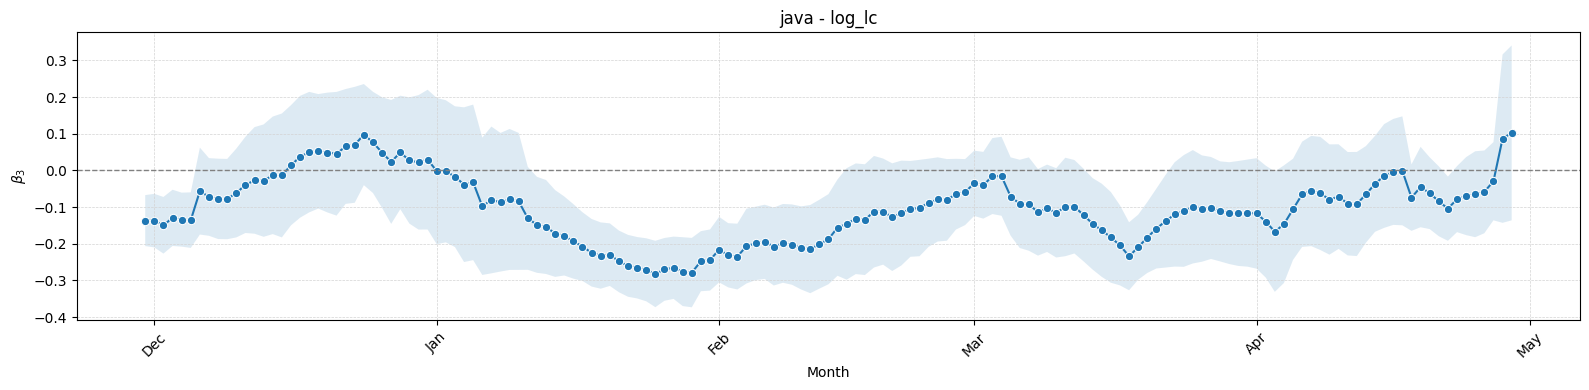

Processing: log_loc


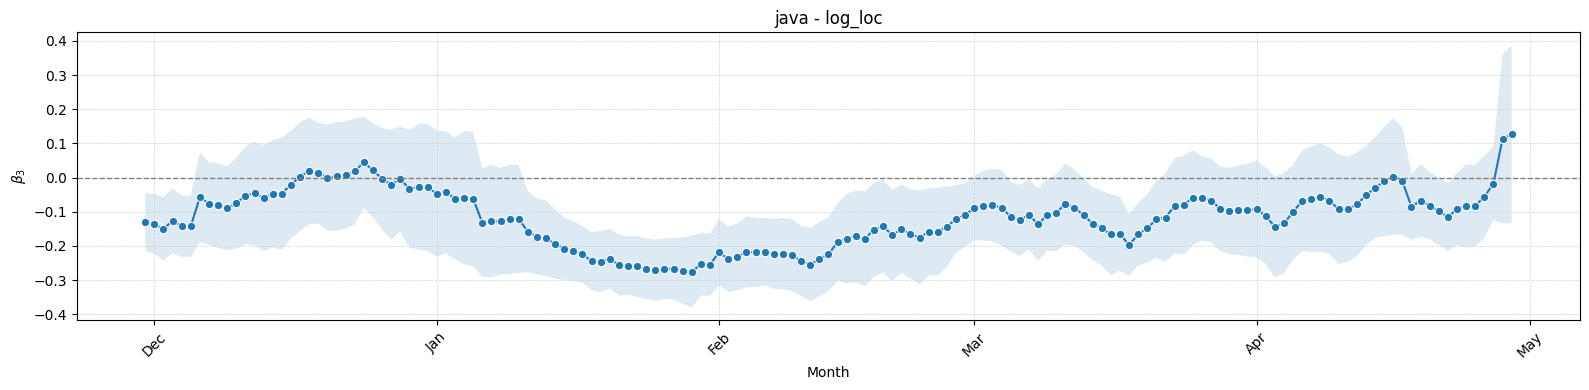

Processing: Medium


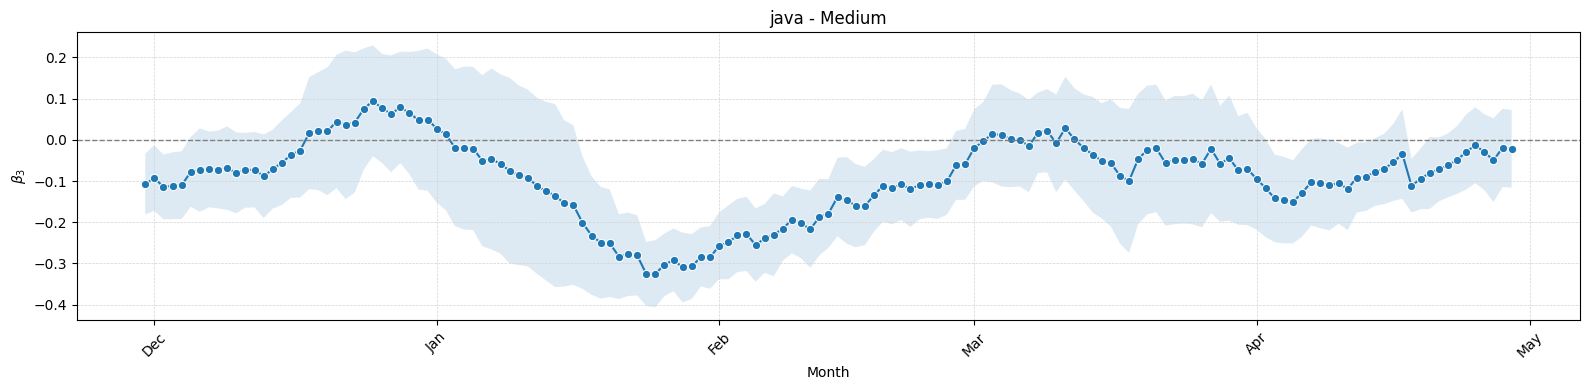

****************************************************************
q23
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.07550392626693474
After matching:  act_pre 0.07856583828707282
Balance: --------------
***********
Before matching:  comm_pre 0.07958152281640915
After matching:  comm_pre 0.08290016996385101
Balance: --------------
***********
Before matching:  ans_pre 0.04776234008285922
After matching:  ans_pre 0.05324122085815607
Balance: --------------
***********
Before matching:  view_pre 0.08947399158331816
After matching:  view_pre 0.09919195212998393
Balance: --------------
***********
Before matching:  sc_pre 0.0008640894497407493
After matching:  sc_pre 0.009339760423968254
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0  22872.0  0.436634  0.032248  0.382234  0.383168  0.

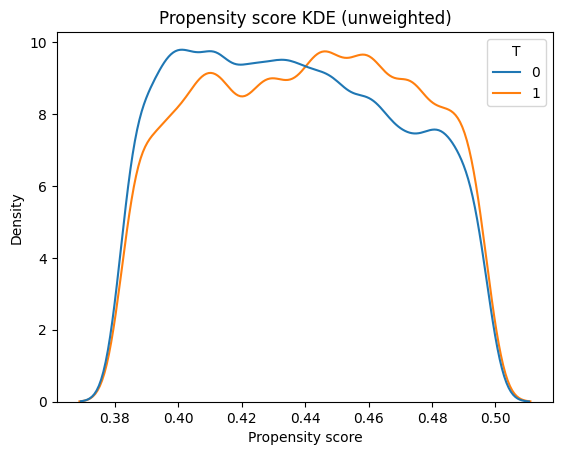

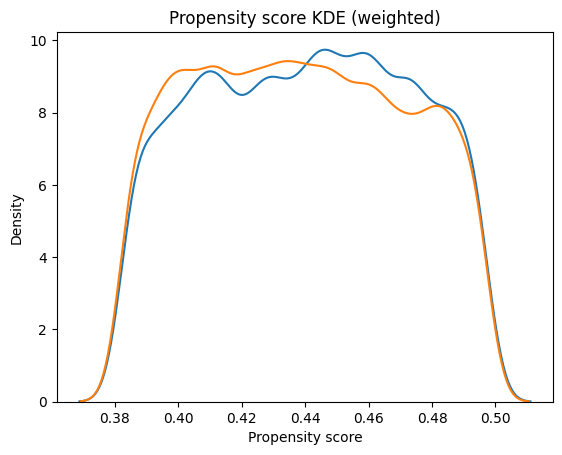

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


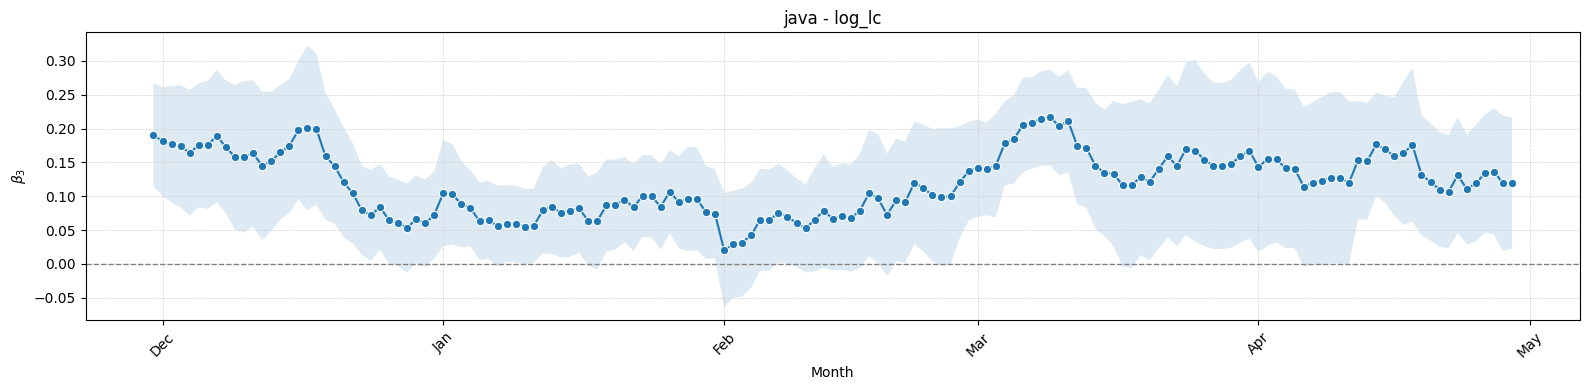

Processing: log_loc
operands could not be broadcast together with shapes (429,1) (428,61) 
Processing: Medium


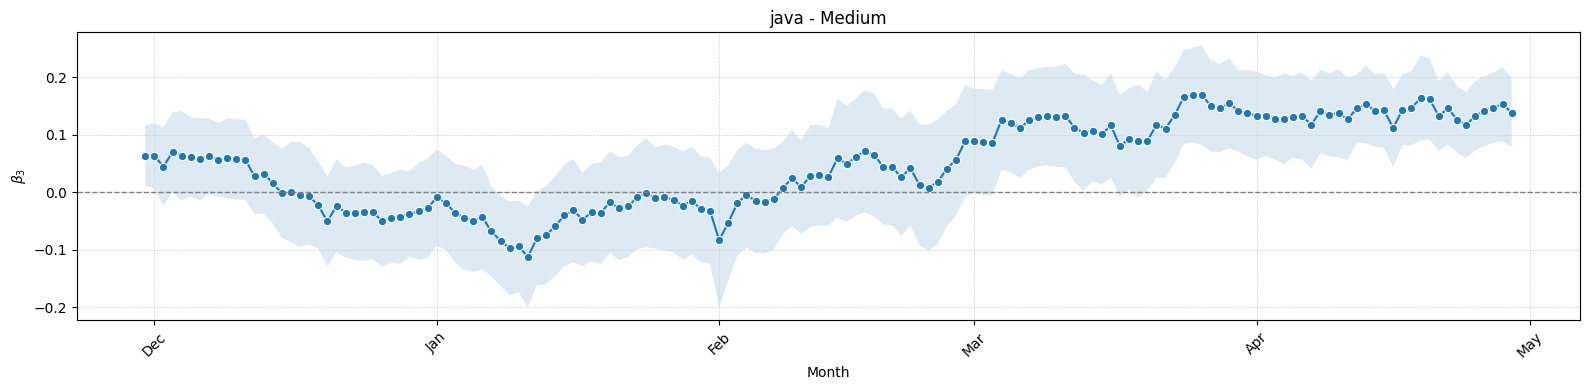

****************************************************************
q4
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.1614230704704319
After matching:  act_pre 0.1673922873058468
Balance: --------------
***********
Before matching:  comm_pre 0.16997554113382446
After matching:  comm_pre 0.17646032672719547
Balance: --------------
***********
Before matching:  ans_pre 0.13410063456648202
After matching:  ans_pre 0.14456347022063862
Balance: --------------
***********
Before matching:  view_pre 0.14218619545788827
After matching:  view_pre 0.15095331575983922
Balance: --------------
***********
Before matching:  sc_pre -0.023931221537347034
After matching:  sc_pre -0.02322846237680585
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0   9588.0  0.541426  0.031886  0.497571  0.498031  0.500

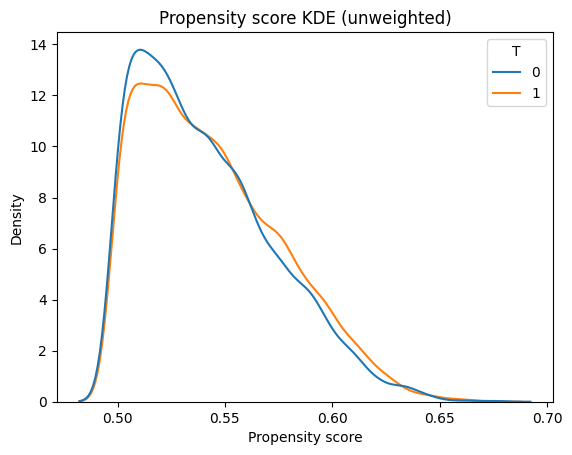

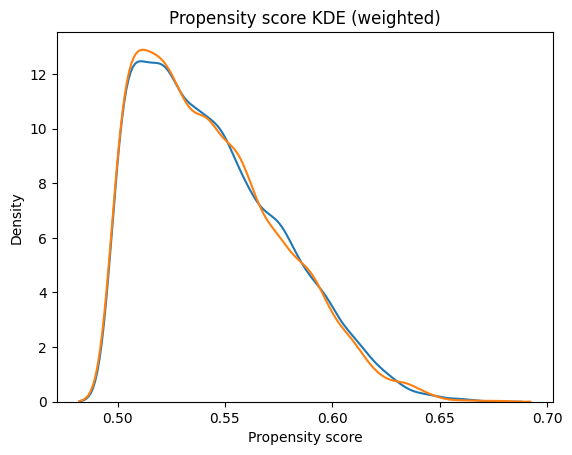

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


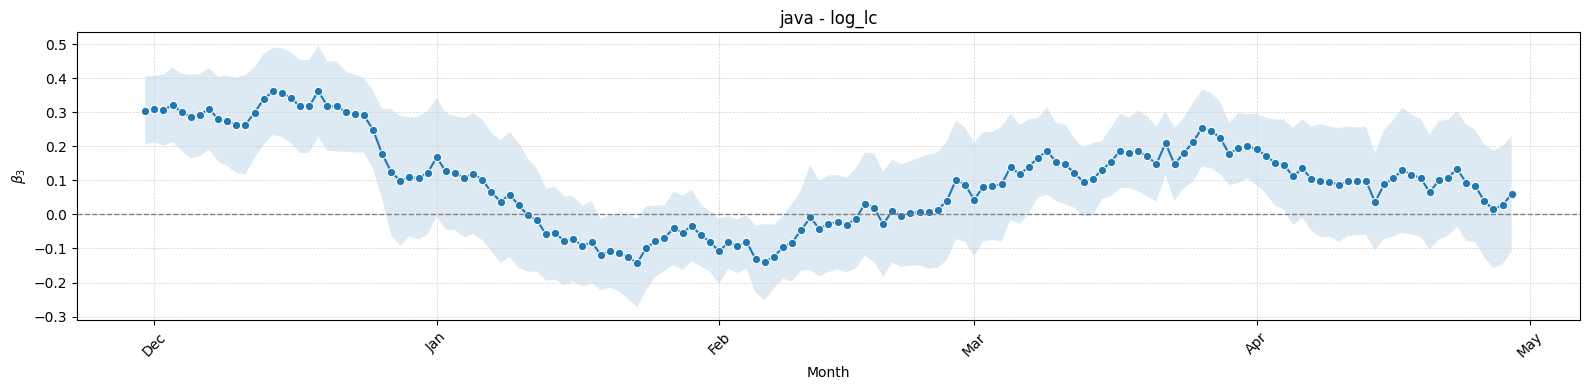

Processing: log_loc


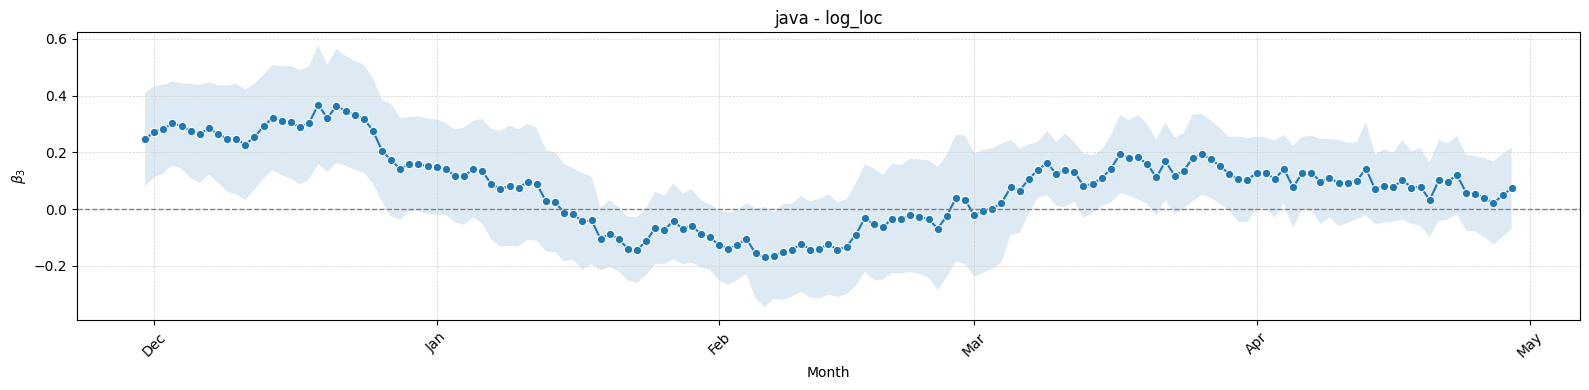

Processing: Medium


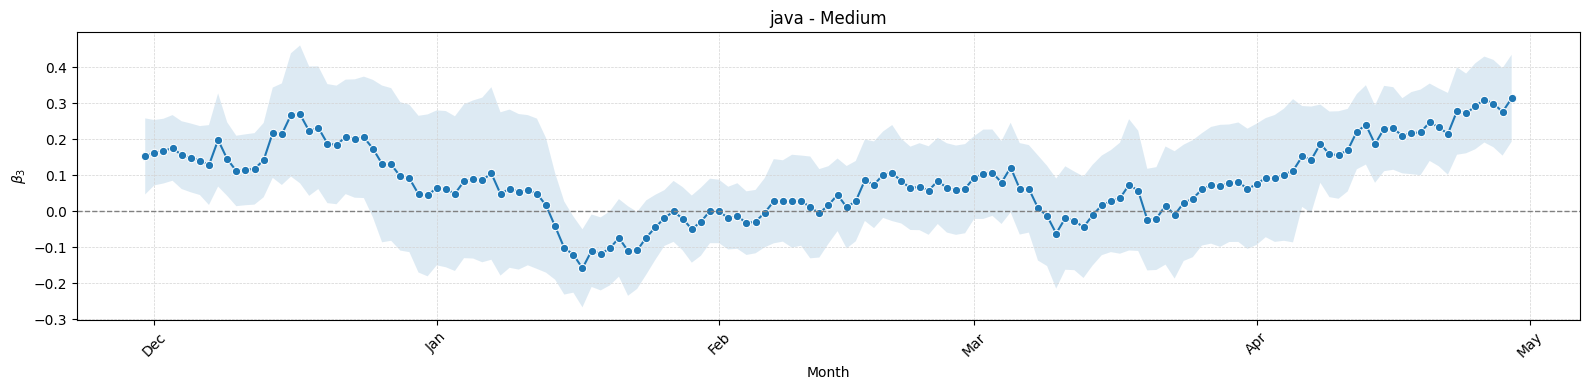

Processing: python
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.664579
         Iterations 5


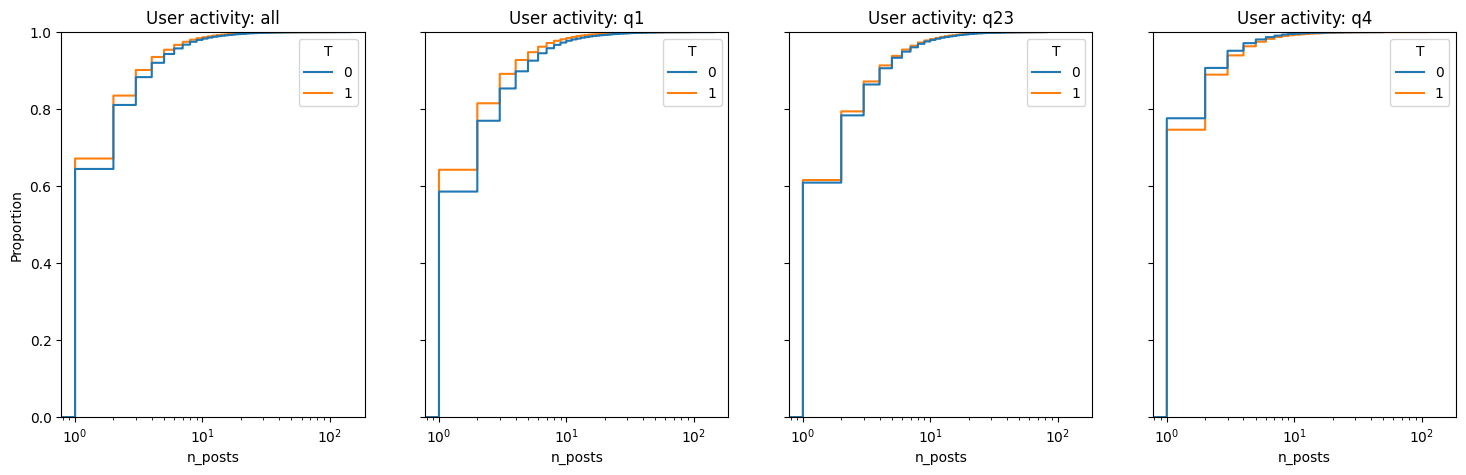

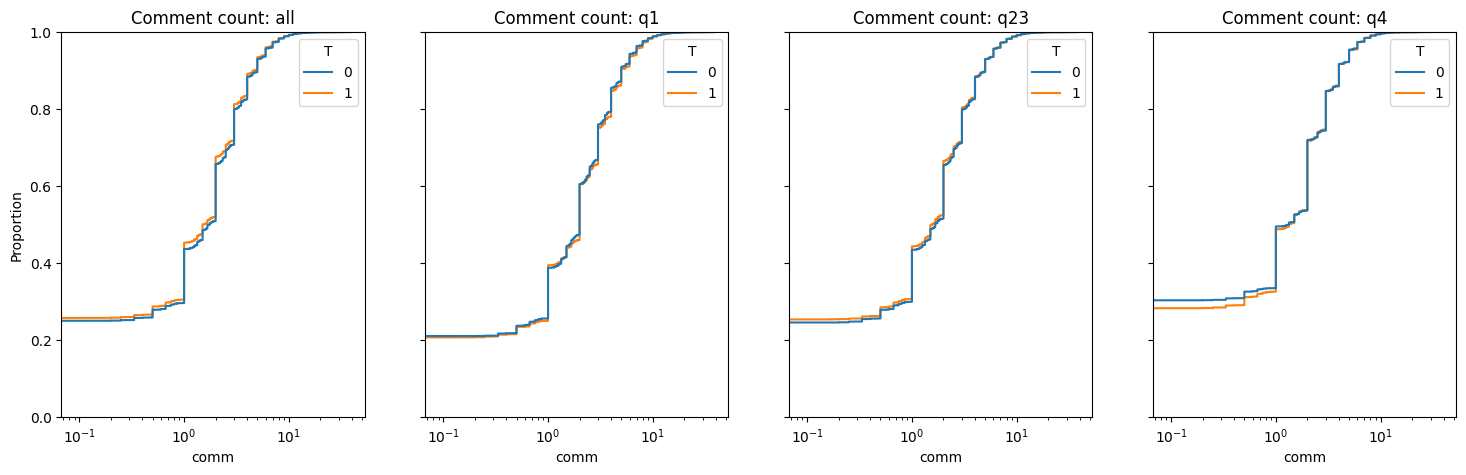

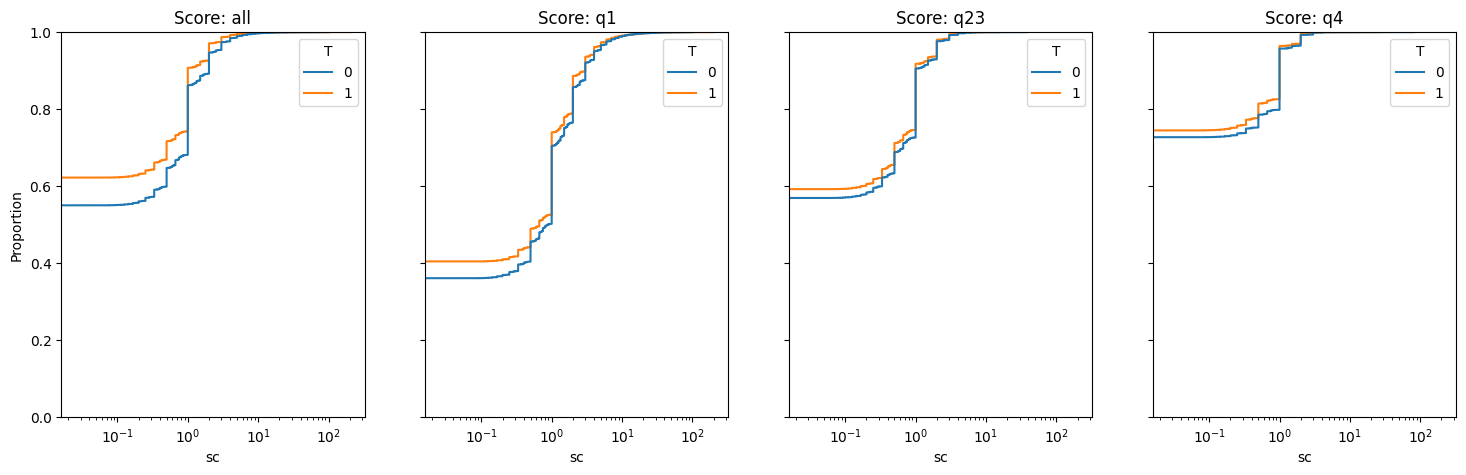

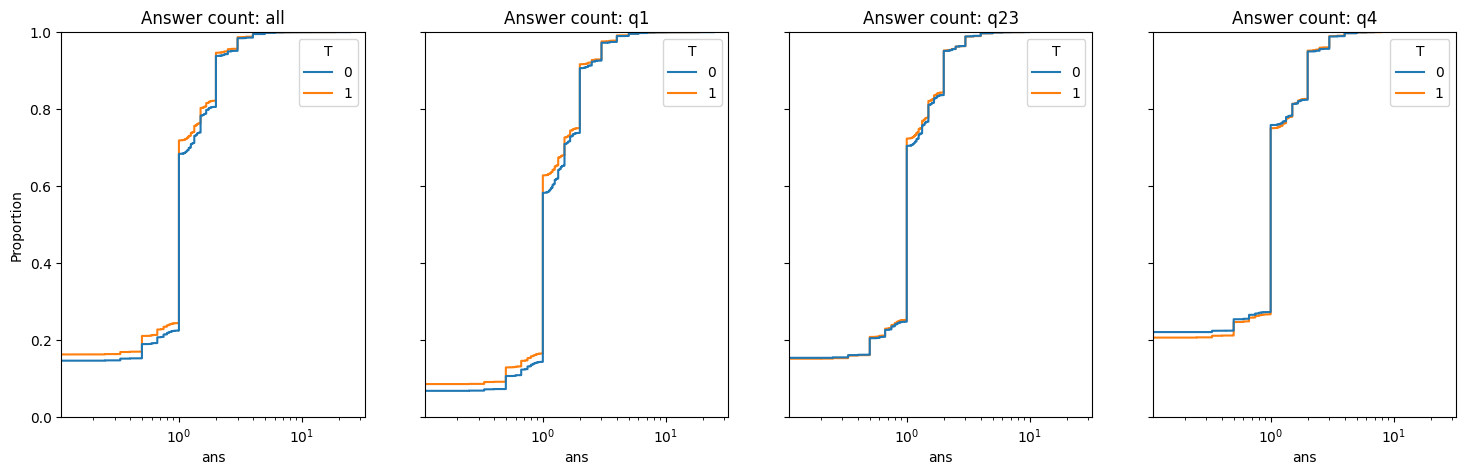

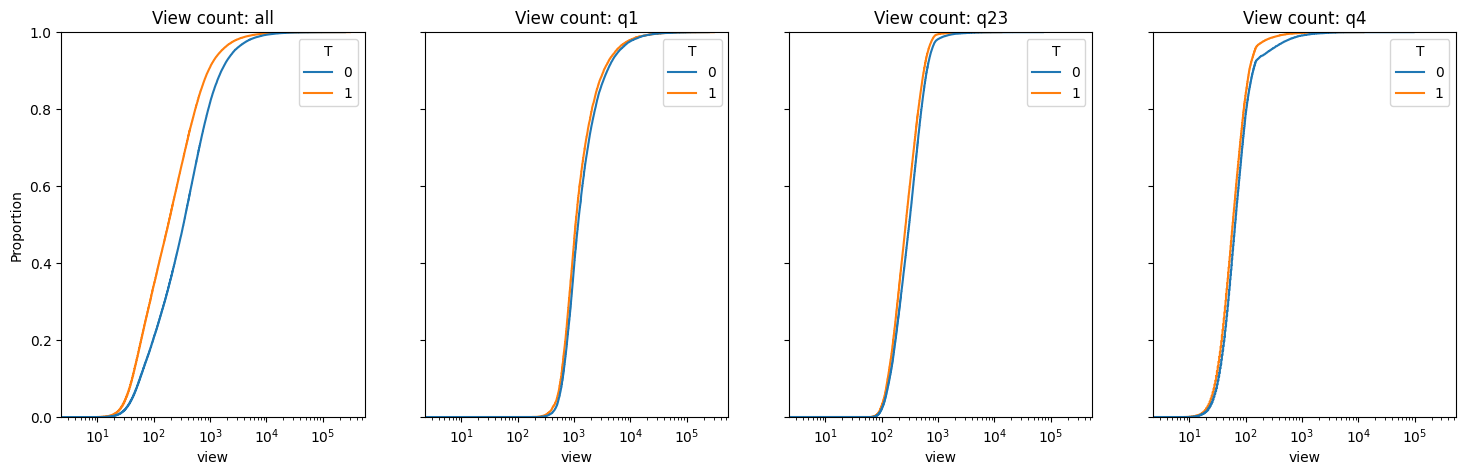

****************************************************************
all
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.08014572333659463
After matching:  act_pre -0.04050768730175285
Balance: --------------
***********
Before matching:  comm_pre -0.10181220116104218
After matching:  comm_pre -0.058648832804014804
Balance: --------------
***********
Before matching:  ans_pre -0.08766647516837349
After matching:  ans_pre -0.04659394550223074
Balance: --------------
***********
Before matching:  view_pre -0.22529428630048515
After matching:  view_pre -0.15489470399872513
Balance: --------------
***********
Before matching:  sc_pre -0.1718354245531565
After matching:  sc_pre -0.10280003274838372
Overlap: --------------
      count      mean       std       min        1%        5%       10%  \
T                                                                         
0  158763.0  0.445031  0.112608  0.001977  0.

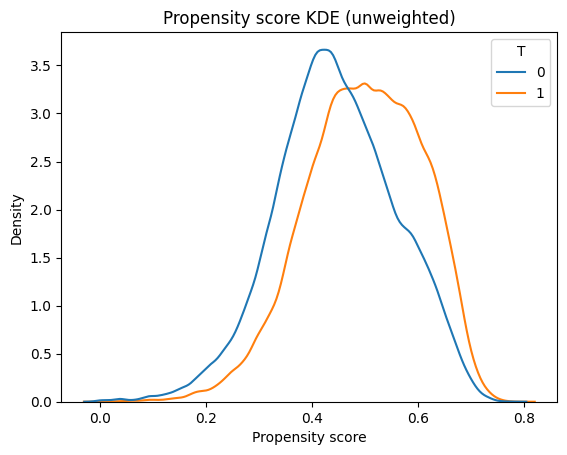

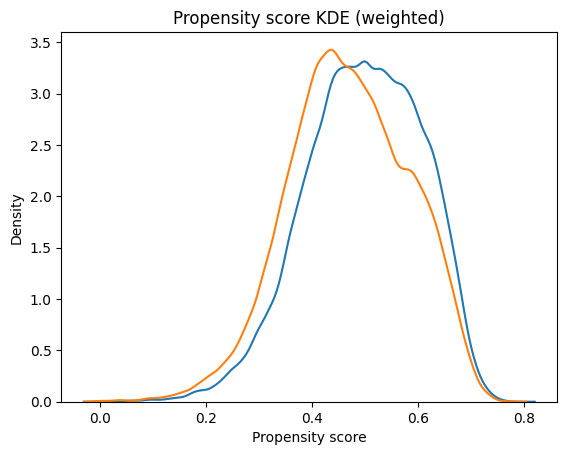

Processing: log_lc


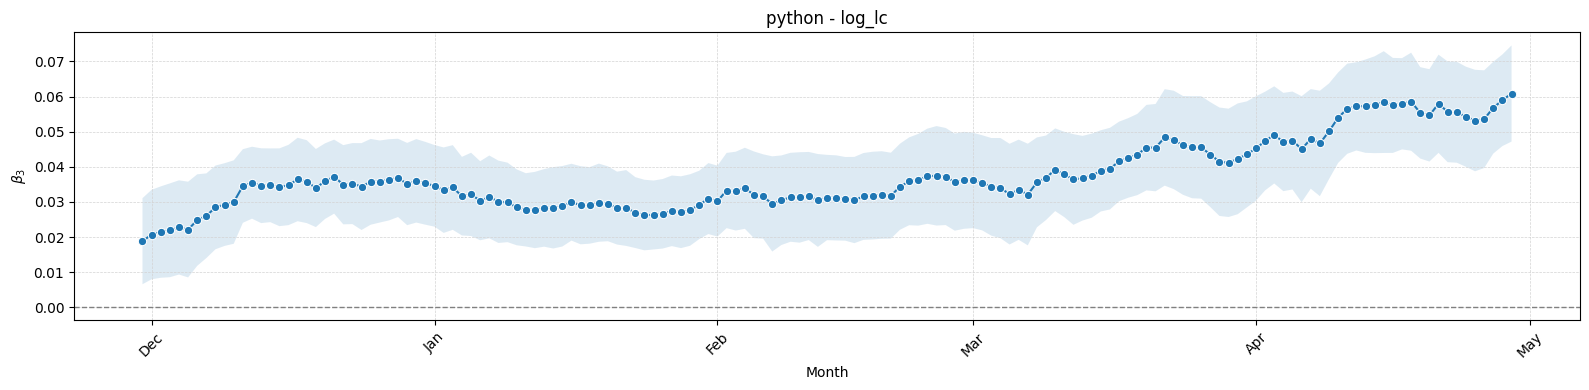

Processing: log_loc


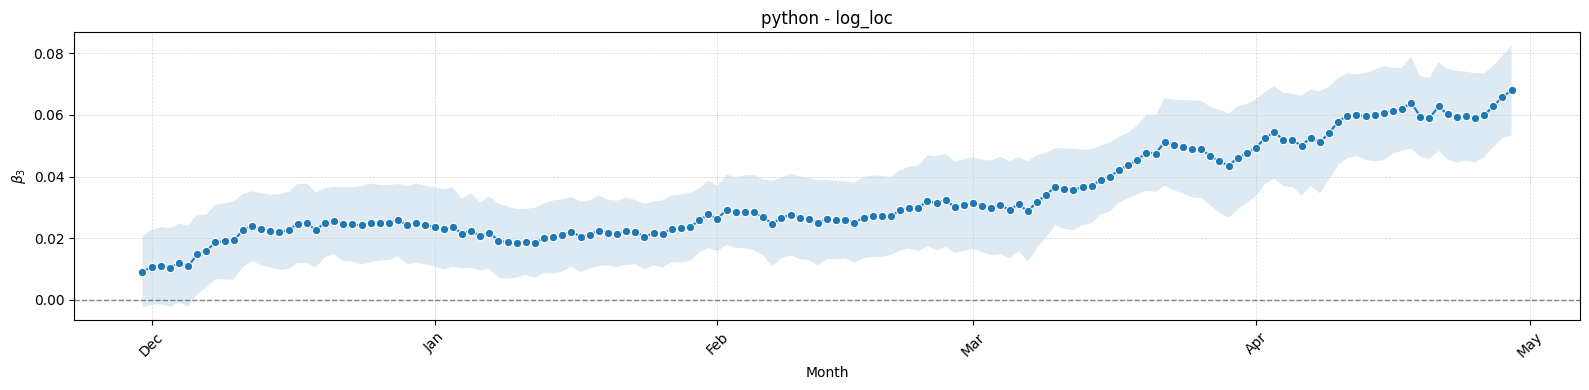

Processing: Medium


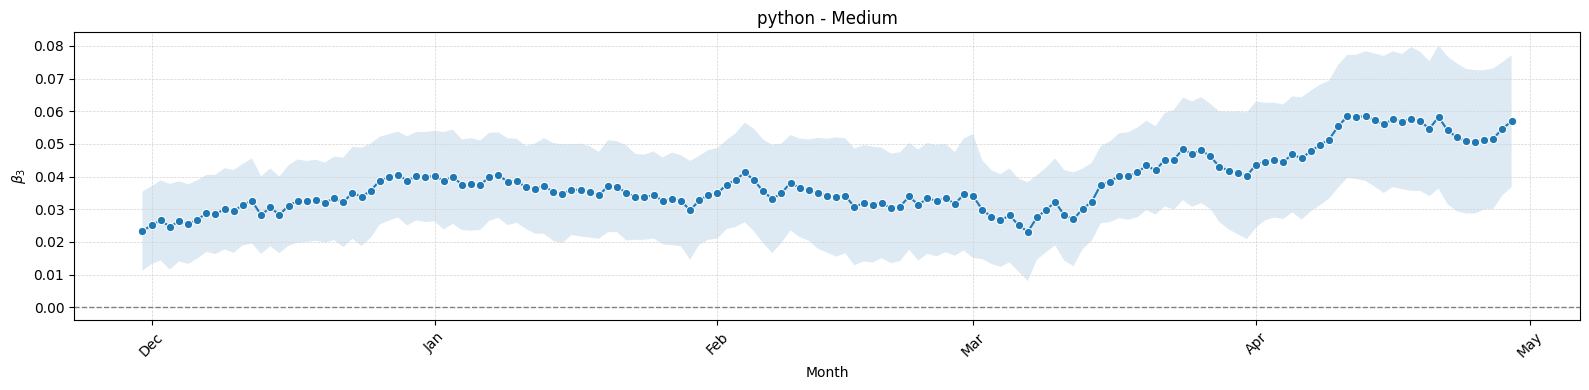

****************************************************************
q1
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.1543115072346104
After matching:  act_pre -0.14735014851724212
Balance: --------------
***********
Before matching:  comm_pre -0.14345043746459946
After matching:  comm_pre -0.13515746986669858
Balance: --------------
***********
Before matching:  ans_pre -0.16224529743696436
After matching:  ans_pre -0.15240002456129587
Balance: --------------
***********
Before matching:  view_pre -0.18904333383731434
After matching:  view_pre -0.1514936890701239
Balance: --------------
***********
Before matching:  sc_pre -0.1604576911180967
After matching:  sc_pre -0.12879906396943852
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0  50980.0  0.320306  0.063082  0.001977  0.106127 

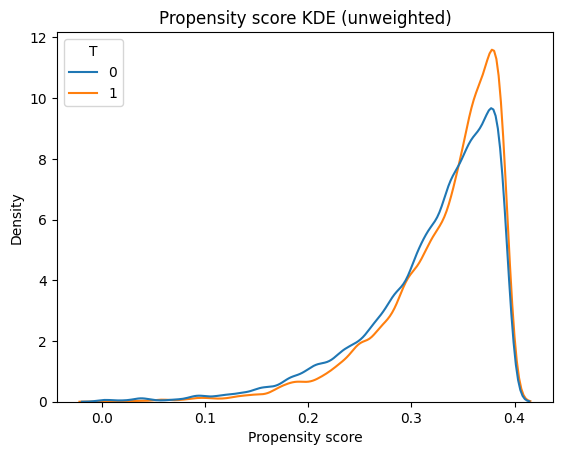

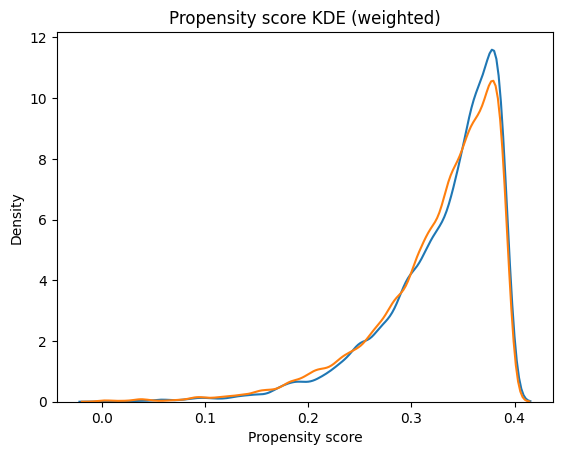

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


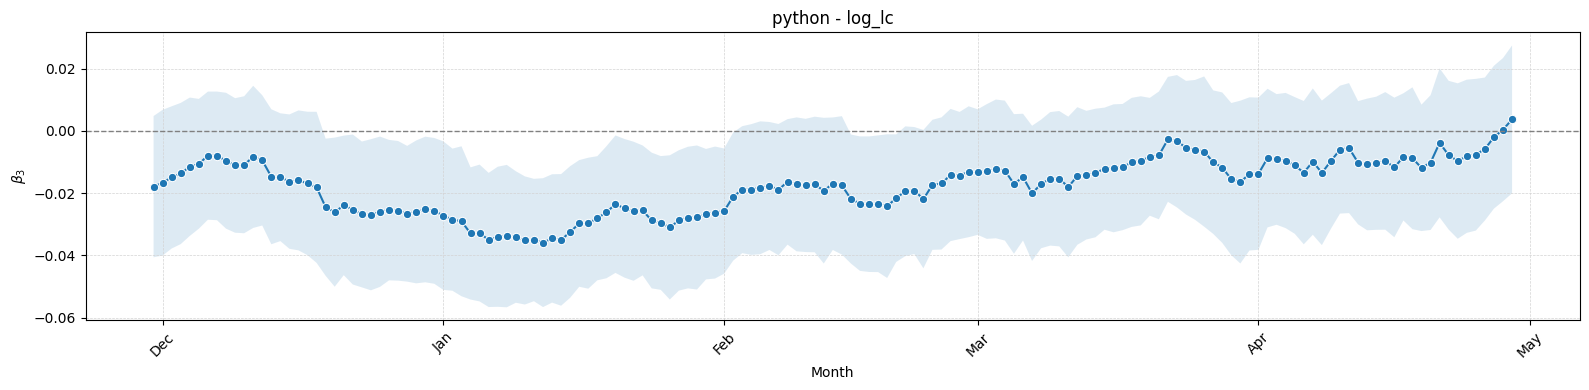

Processing: log_loc


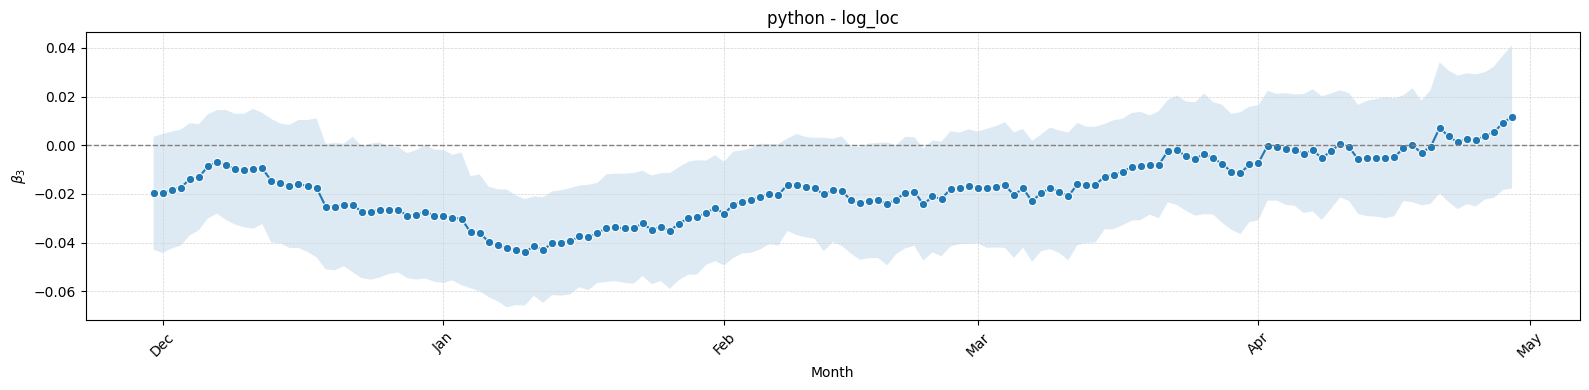

Processing: Medium


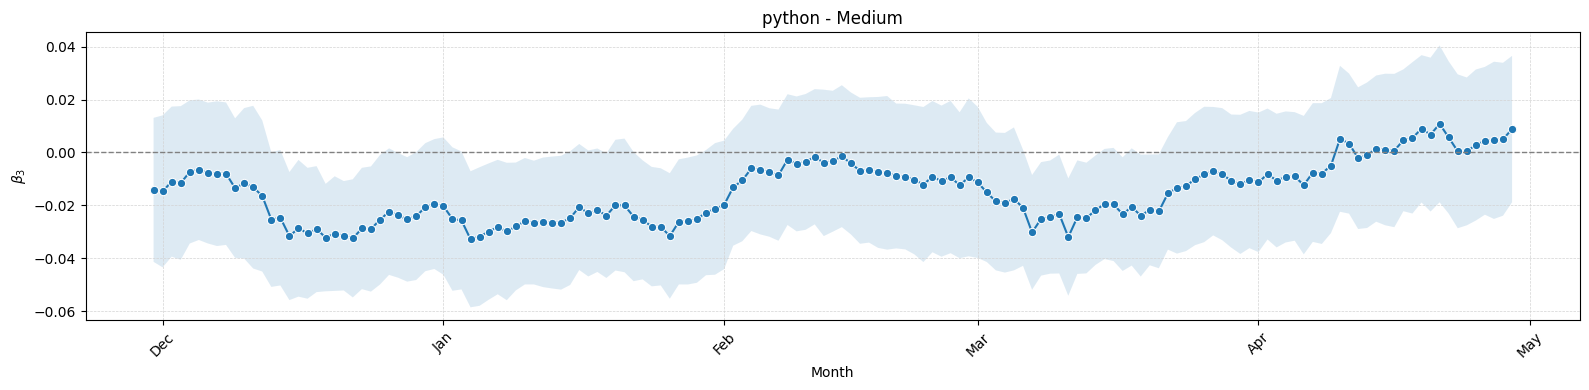

****************************************************************
q23
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.04836348045321701
After matching:  act_pre -0.04308294584188537
Balance: --------------
***********
Before matching:  comm_pre -0.05303558503091038
After matching:  comm_pre -0.04731157607127297
Balance: --------------
***********
Before matching:  ans_pre -0.057288296422710445
After matching:  ans_pre -0.05261479210785895
Balance: --------------
***********
Before matching:  view_pre -0.13936490272898094
After matching:  view_pre -0.12000942279234322
Balance: --------------
***********
Before matching:  sc_pre -0.011706995962690429
After matching:  sc_pre 0.005238228406973397
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0  79445.0  0.465992  0.045068  0.392745  0.3

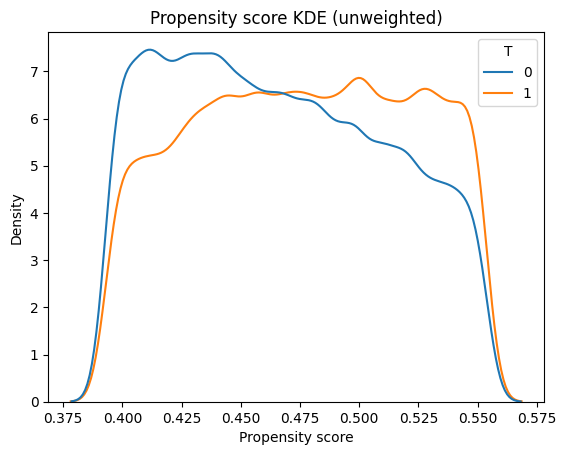

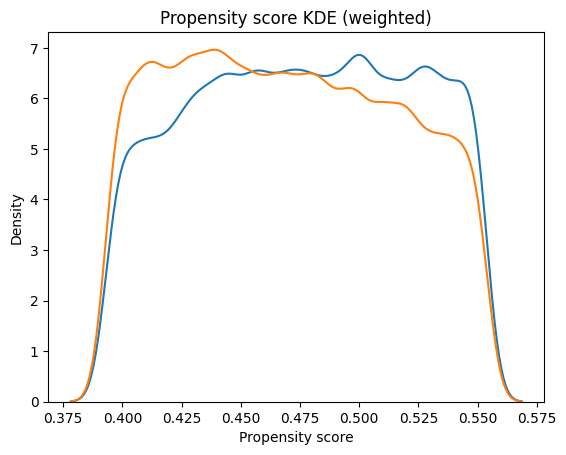

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


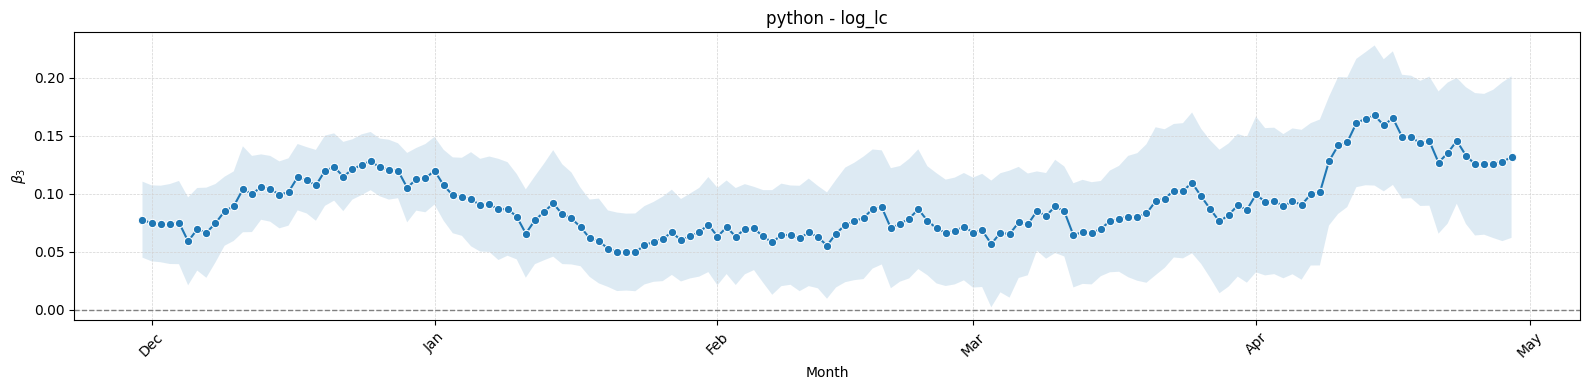

Processing: log_loc


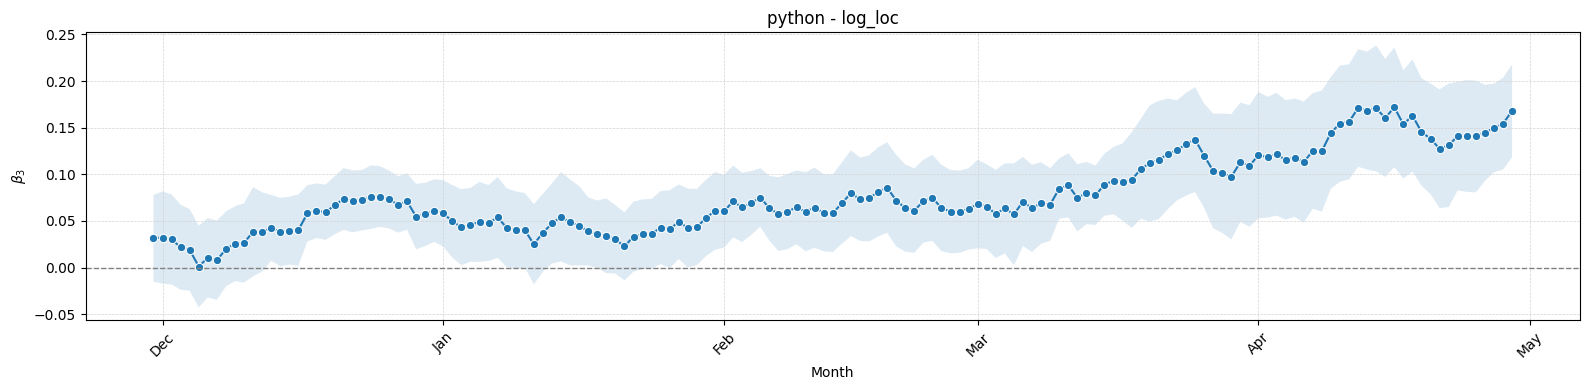

Processing: Medium


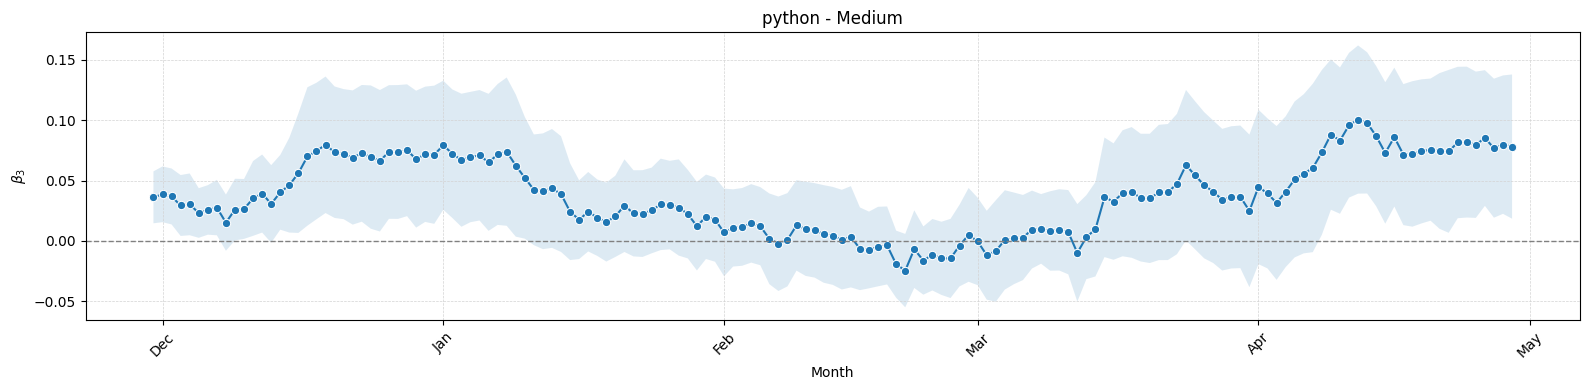

****************************************************************
q4
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.22940970447535644
After matching:  act_pre 0.23735491081754073
Balance: --------------
***********
Before matching:  comm_pre 0.1905494495629687
After matching:  comm_pre 0.20192547063256663
Balance: --------------
***********
Before matching:  ans_pre 0.2172373585902439
After matching:  ans_pre 0.22531326430768356
Balance: --------------
***********
Before matching:  view_pre 0.16803806186601214
After matching:  view_pre 0.1764856880831244
Balance: --------------
***********
Before matching:  sc_pre 0.135367207117536
After matching:  sc_pre 0.13953848034418376
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0  28338.0  0.610650  0.039265  0.553982  0.554938  0.558696  0

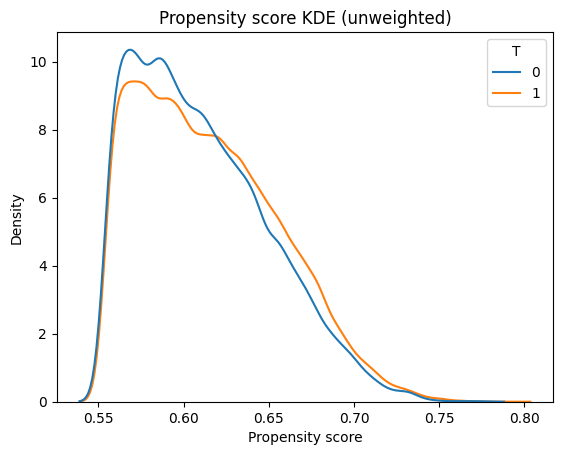

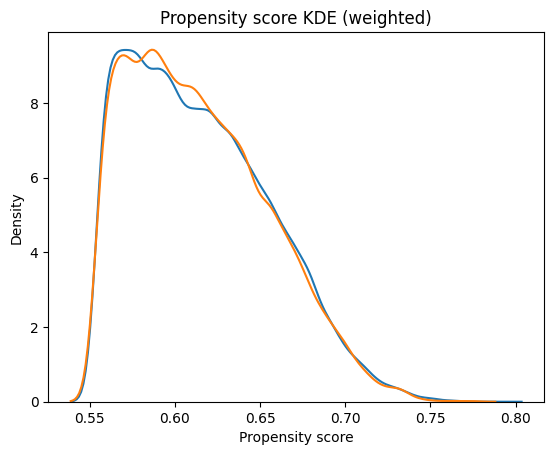

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


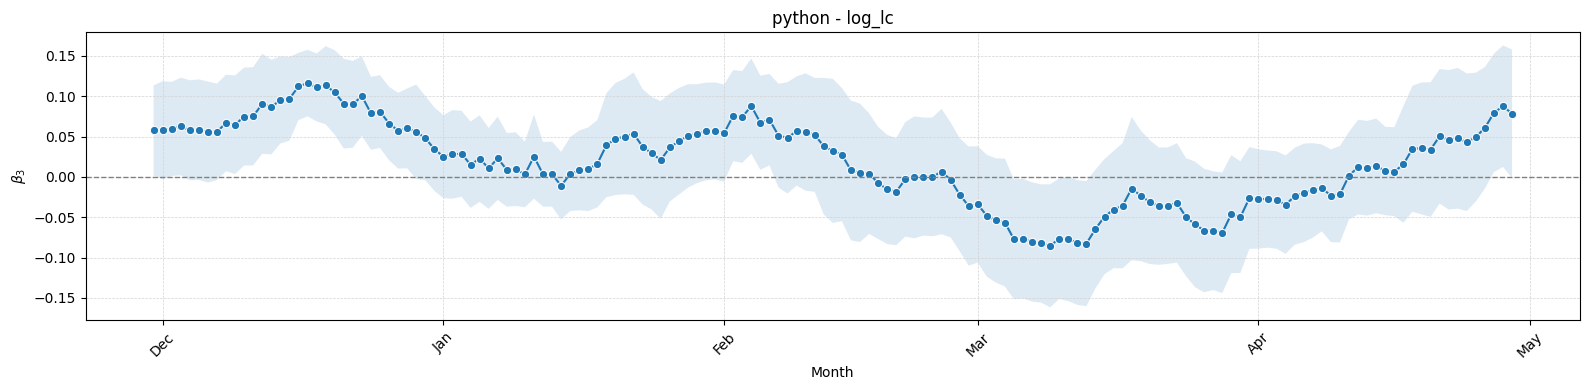

Processing: log_loc


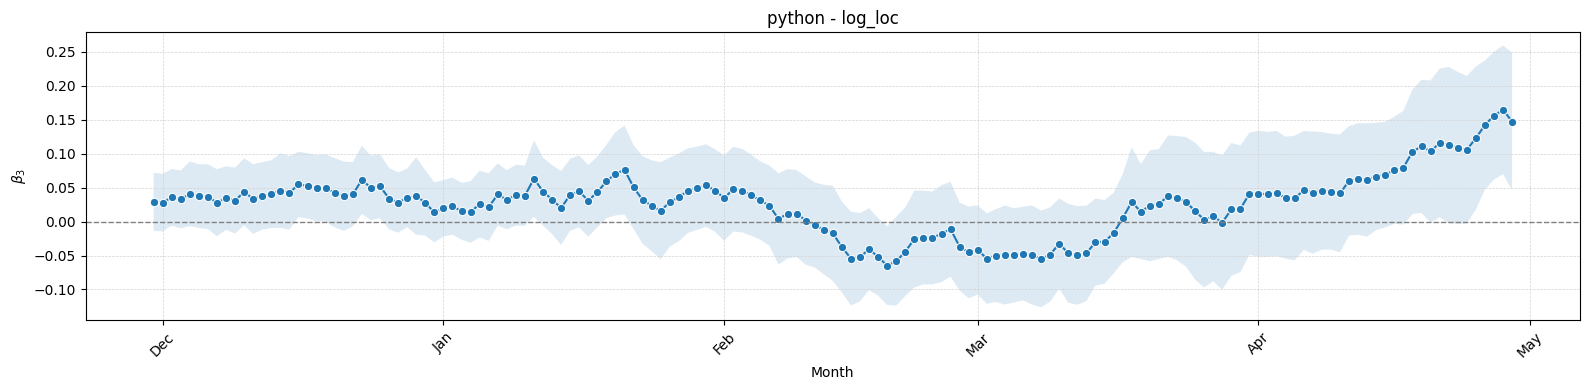

Processing: Medium


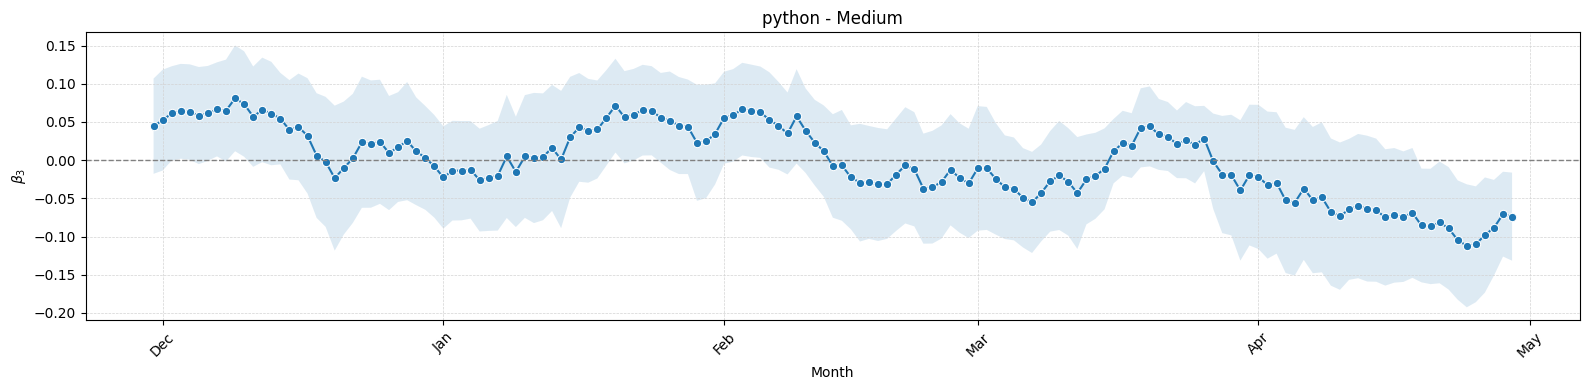

Processing: web
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.667697
         Iterations 6


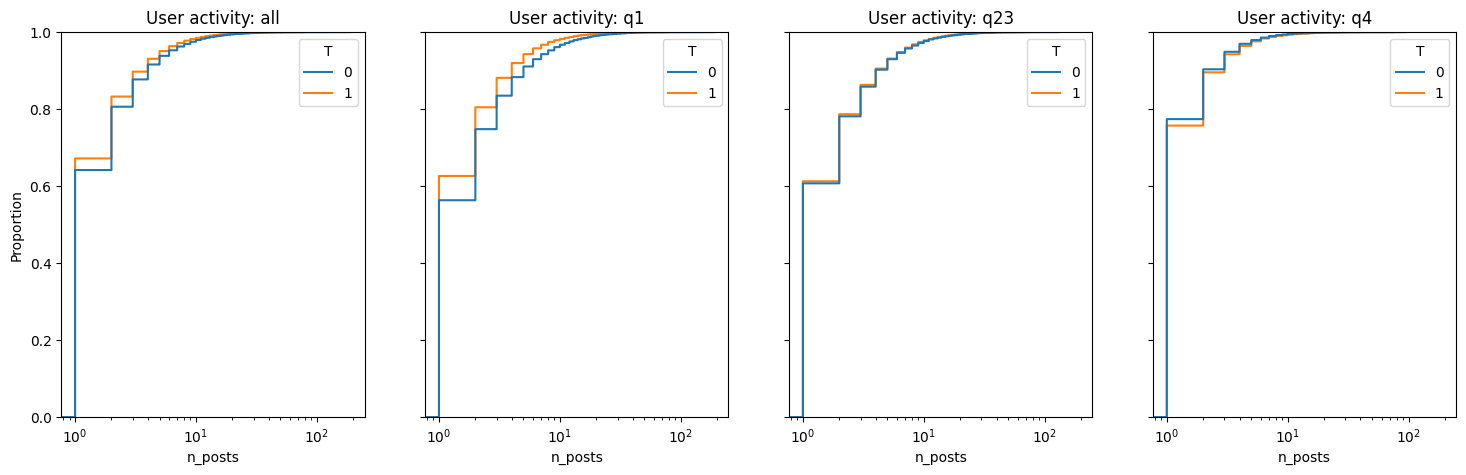

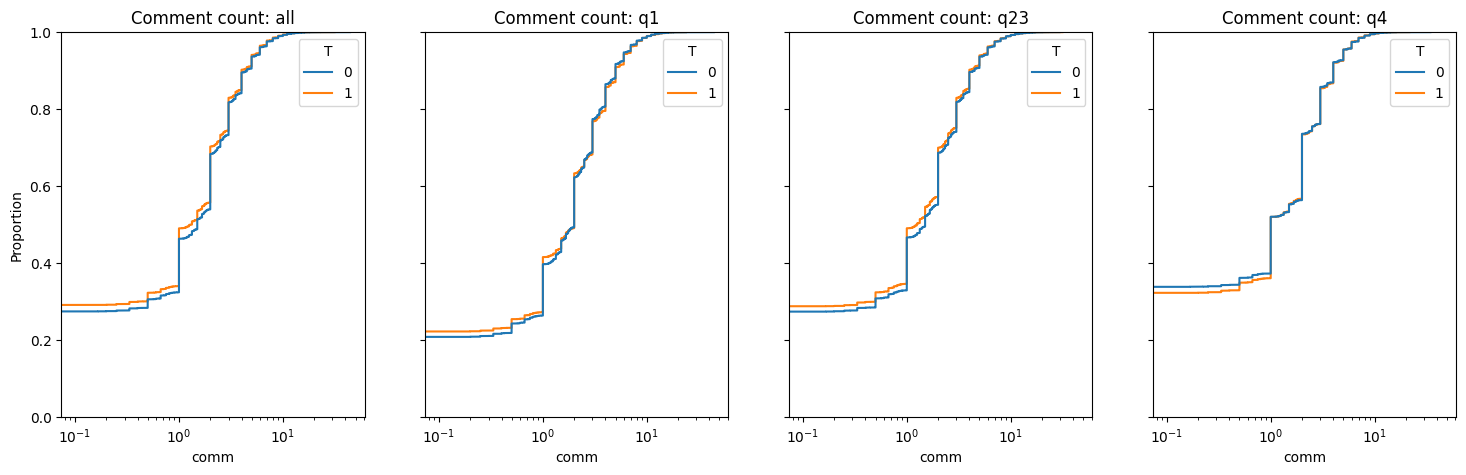

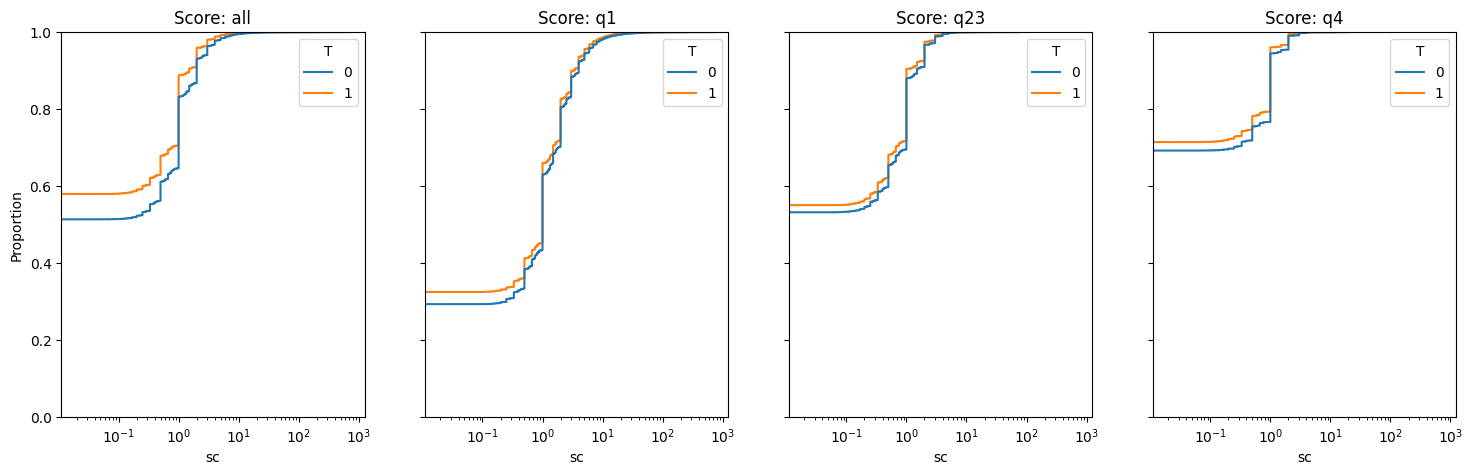

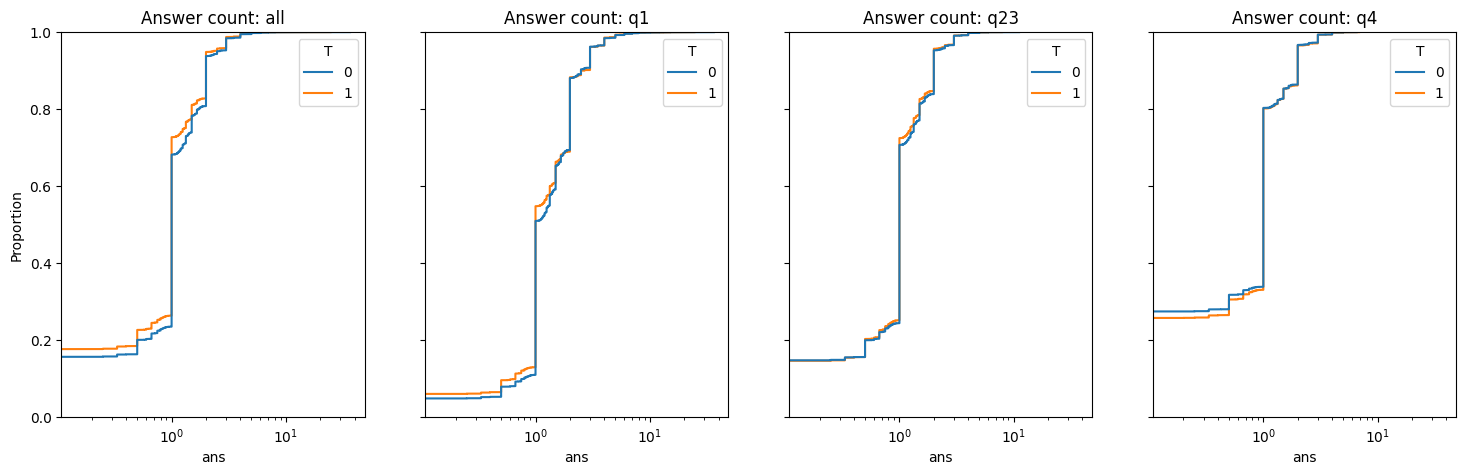

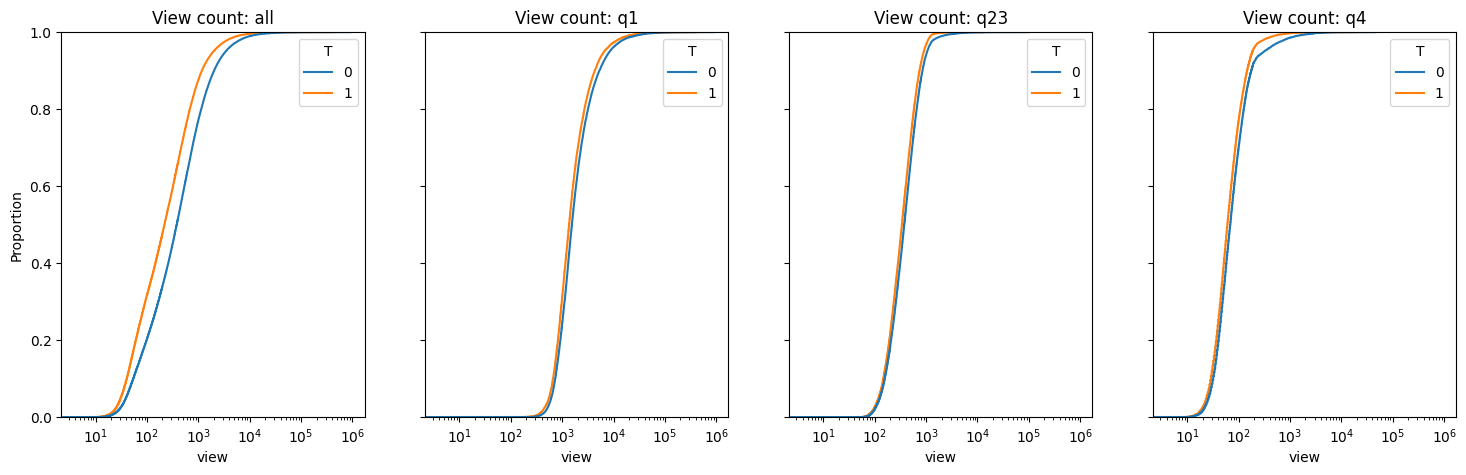

****************************************************************
all
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.10093175047550171
After matching:  act_pre -0.06104280715840431
Balance: --------------
***********
Before matching:  comm_pre -0.11703421886208593
After matching:  comm_pre -0.07660519157796161
Balance: --------------
***********
Before matching:  ans_pre -0.12966765519884518
After matching:  ans_pre -0.08482674606772522
Balance: --------------
***********
Before matching:  view_pre -0.20530506812971203
After matching:  view_pre -0.1507601316727478
Balance: --------------
***********
Before matching:  sc_pre -0.1523784303785937
After matching:  sc_pre -0.10132341002478552
Overlap: --------------
      count      mean       std           min        1%        5%       10%  \
T                                                                             
0  175046.0  0.437148  0.103234  9.5392

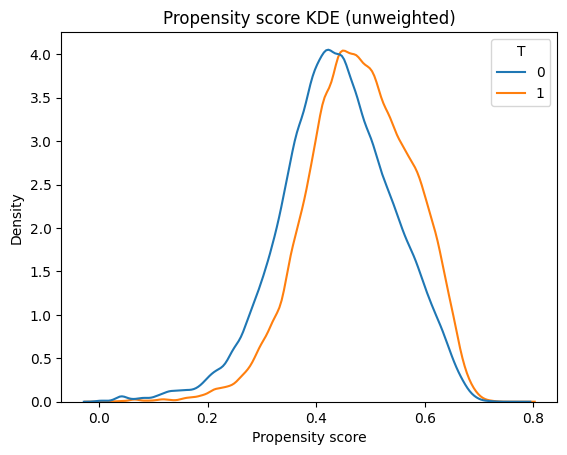

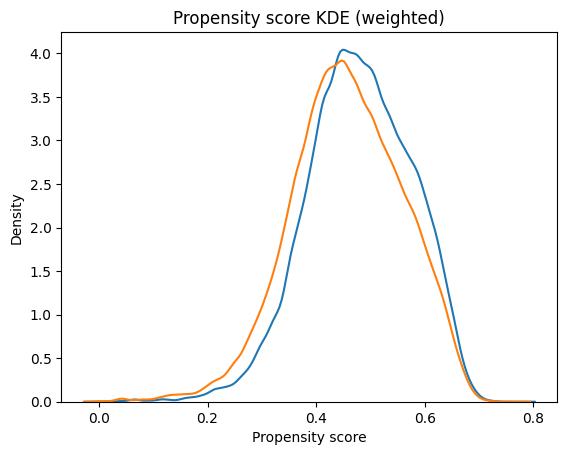

Processing: log_lc


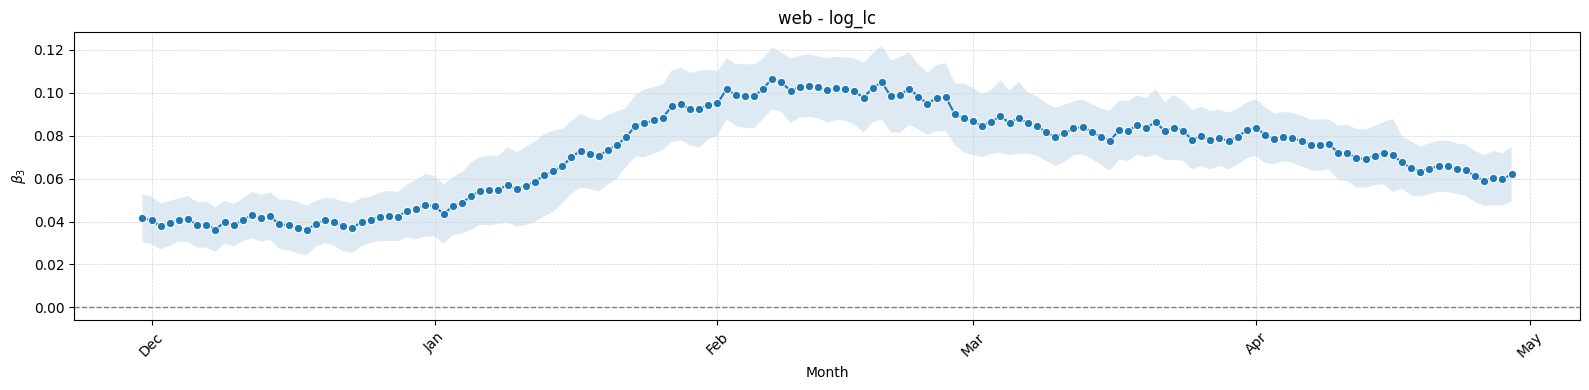

Processing: log_loc


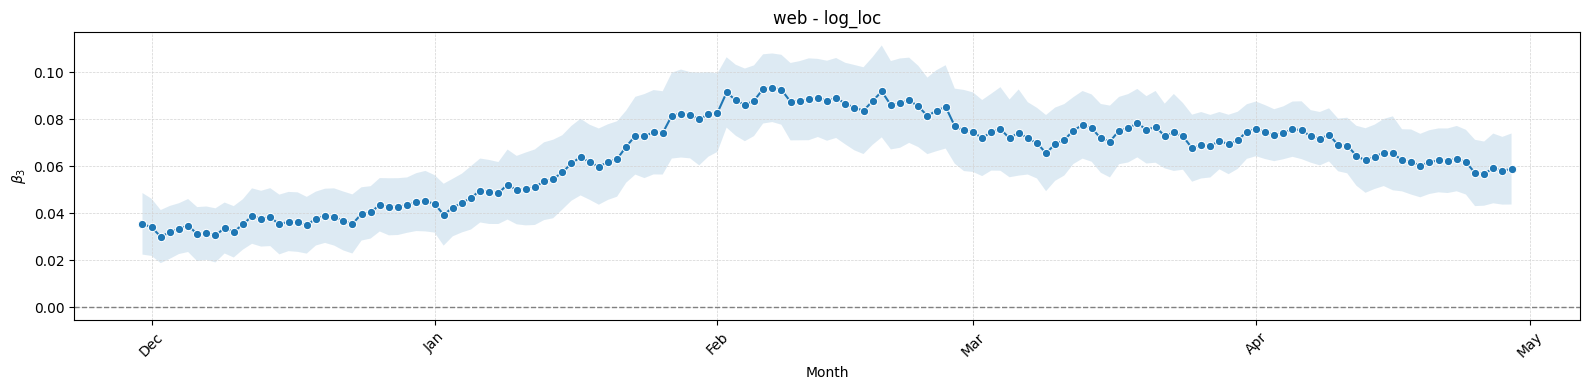

Processing: Medium


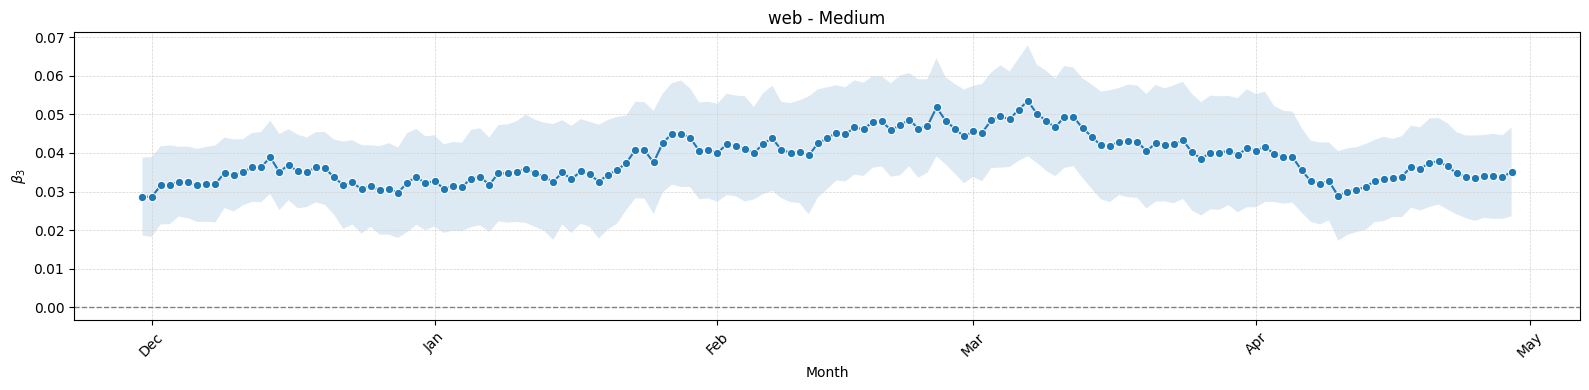

****************************************************************
q1
****************************************************************
Balance: --------------
***********
Before matching:  act_pre -0.21980932545397663
After matching:  act_pre -0.20711200301898783
Balance: --------------
***********
Before matching:  comm_pre -0.20251472399796058
After matching:  comm_pre -0.18912275217850727
Balance: --------------
***********
Before matching:  ans_pre -0.23898246217953492
After matching:  ans_pre -0.22334569551000402
Balance: --------------
***********
Before matching:  view_pre -0.22329065685664187
After matching:  view_pre -0.19662068089285864
Balance: --------------
***********
Before matching:  sc_pre -0.15040649399177225
After matching:  sc_pre -0.11990358713734808
Overlap: --------------
     count      mean       std           min        1%        5%       10%  \
T                                                                            
0  55349.0  0.321663  0.063493  9.539281

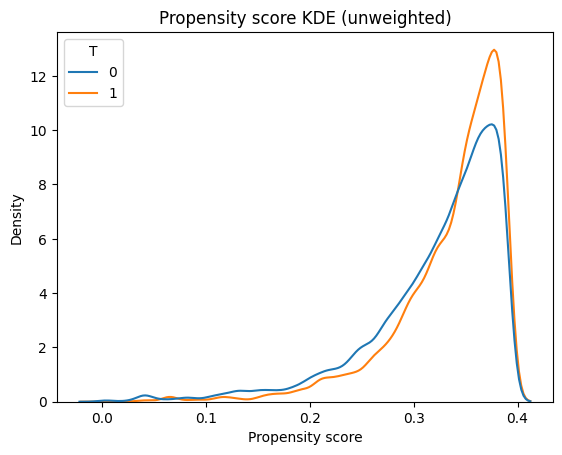

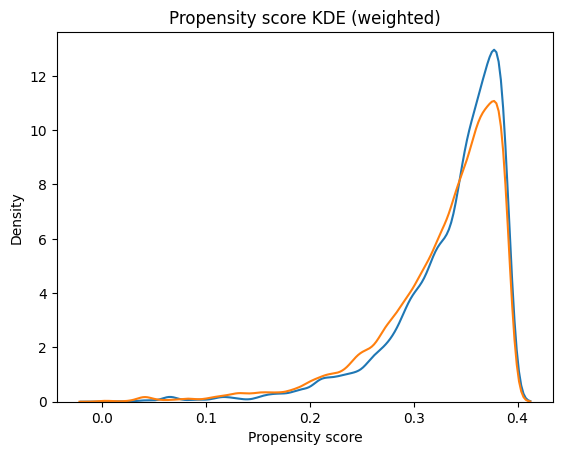

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


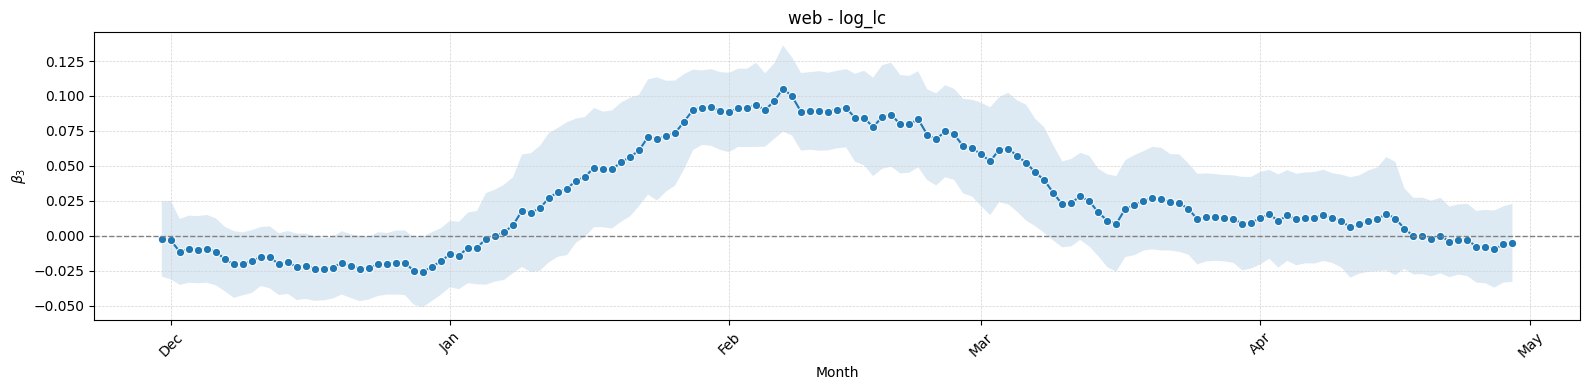

Processing: log_loc


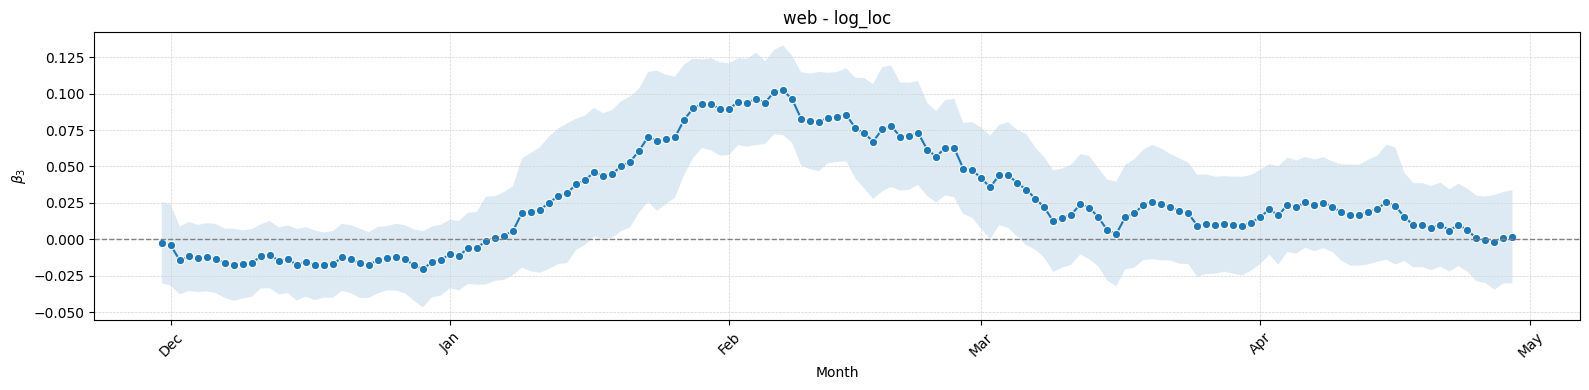

Processing: Medium


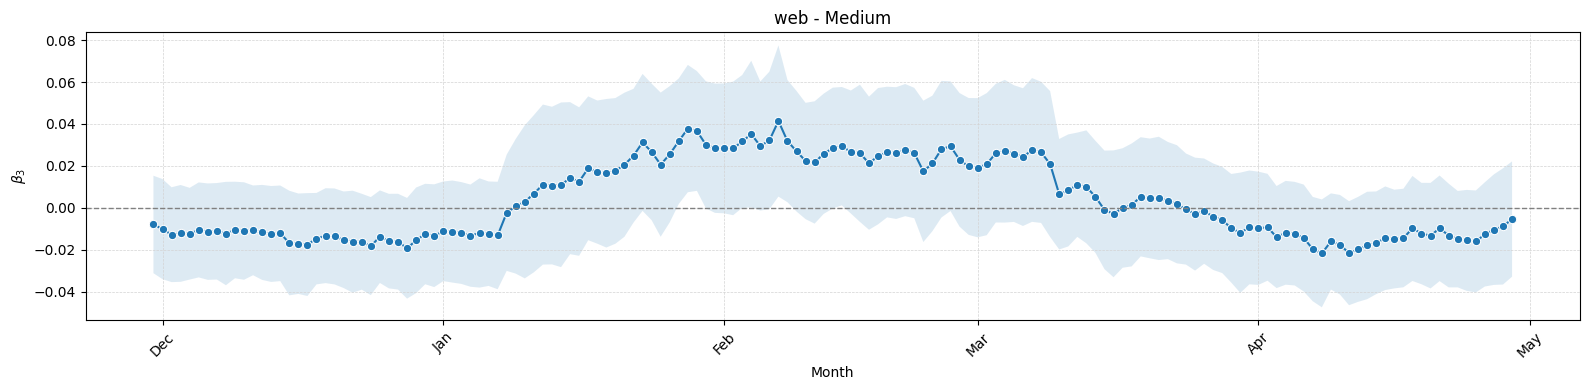

****************************************************************
q23
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.00877350048621633
After matching:  act_pre 0.014536969889827866
Balance: --------------
***********
Before matching:  comm_pre -0.00867247184468097
After matching:  comm_pre -0.0024224945161379265
Balance: --------------
***********
Before matching:  ans_pre -0.011982401354000225
After matching:  ans_pre -0.005675533003516941
Balance: --------------
***********
Before matching:  view_pre -0.04579485346845136
After matching:  view_pre -0.029780280082223776
Balance: --------------
***********
Before matching:  sc_pre 0.0043295582466899
After matching:  sc_pre 0.01832946427469714
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                        
0  85888.0  0.454843  0.038427  0.390918  0.39

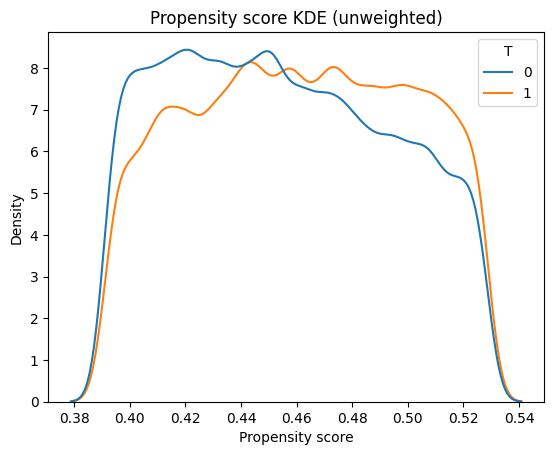

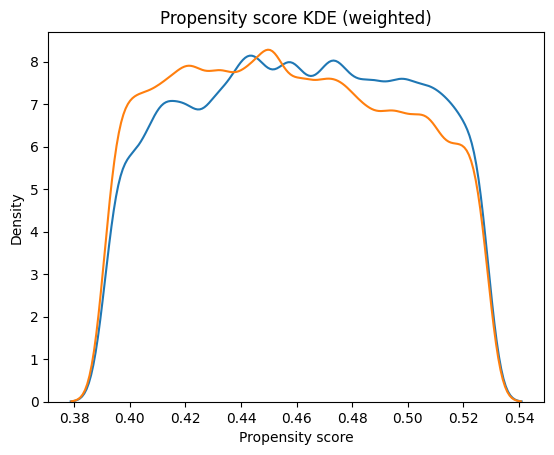

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


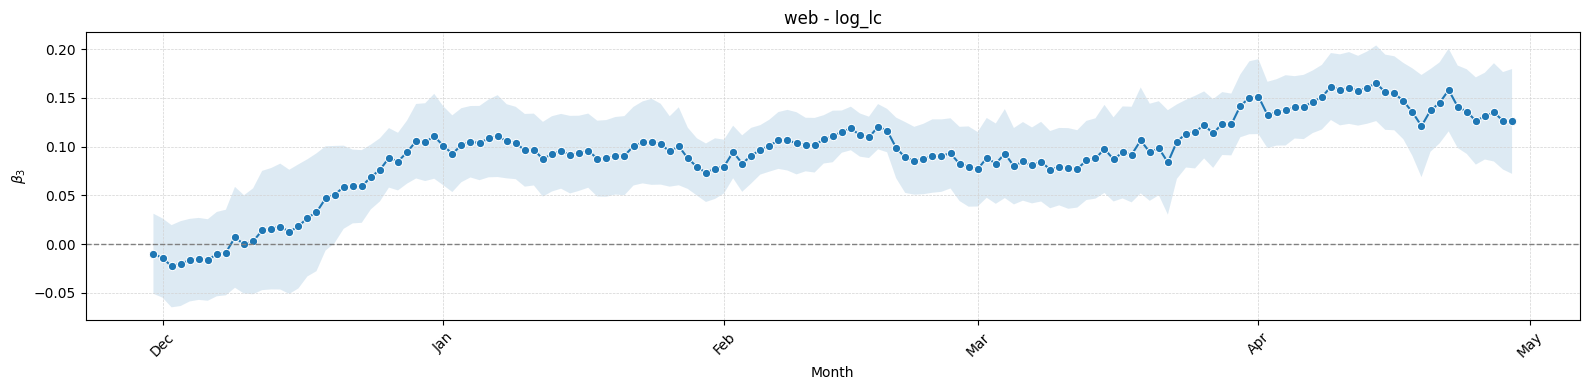

Processing: log_loc


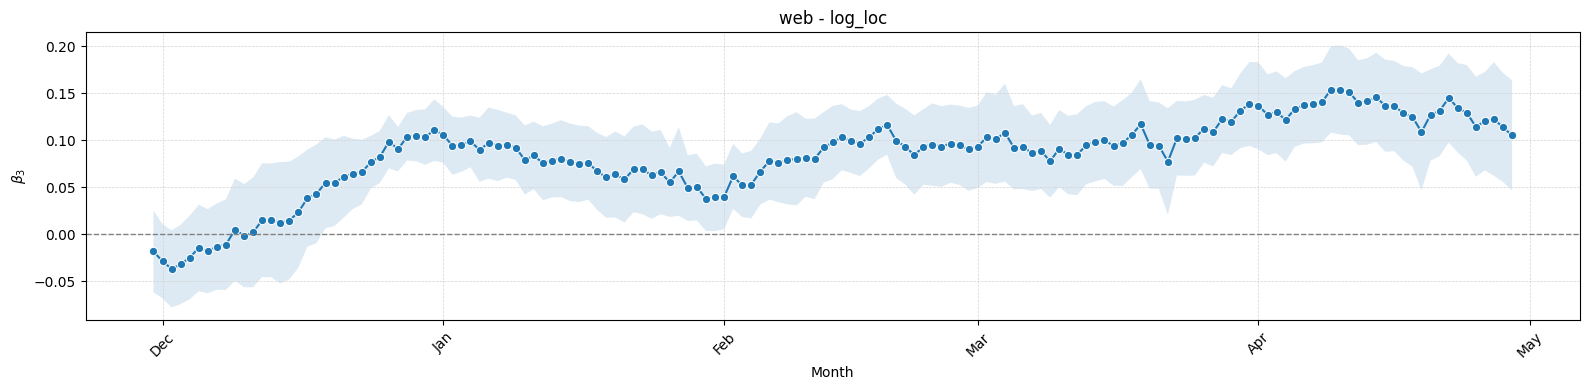

Processing: Medium


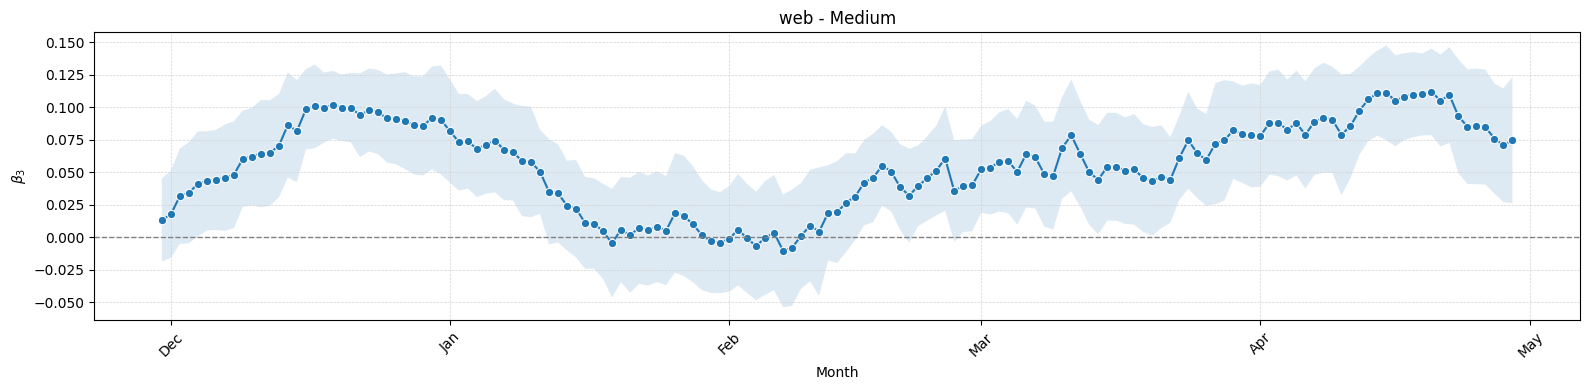

****************************************************************
q4
****************************************************************
Balance: --------------
***********
Before matching:  act_pre 0.05869093407997554
After matching:  act_pre 0.07135839068857004
Balance: --------------
***********
Before matching:  comm_pre 0.008677591644378802
After matching:  comm_pre 0.02238775083098406
Balance: --------------
***********
Before matching:  ans_pre 0.04249609458514647
After matching:  ans_pre 0.05501443586551926
Balance: --------------
***********
Before matching:  view_pre -0.02359192722134357
After matching:  view_pre -0.010797758509958837
Balance: --------------
***********
Before matching:  sc_pre 0.045874538567324936
After matching:  sc_pre 0.05093858738333206
Overlap: --------------
     count      mean       std       min        1%        5%      10%  \
T                                                                       
0  33809.0  0.581256  0.037817  0.528791  0.529639  0.5

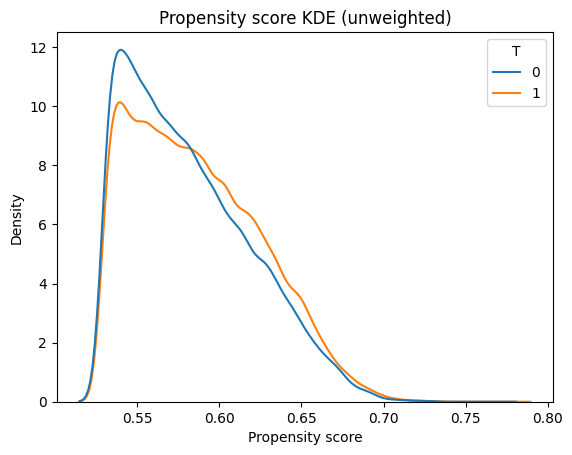

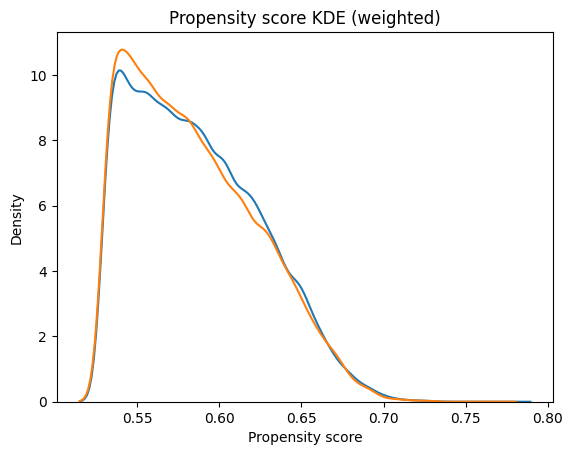

c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{col}_w'] = w * data[col]
c:\Users\denis\work\src\so\so.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

Processing: log_lc


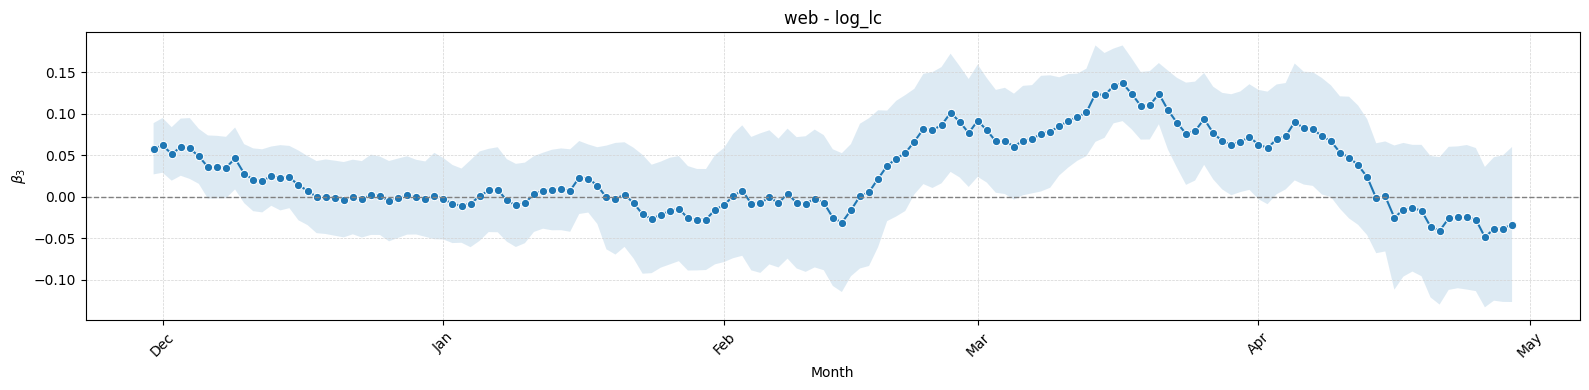

Processing: log_loc


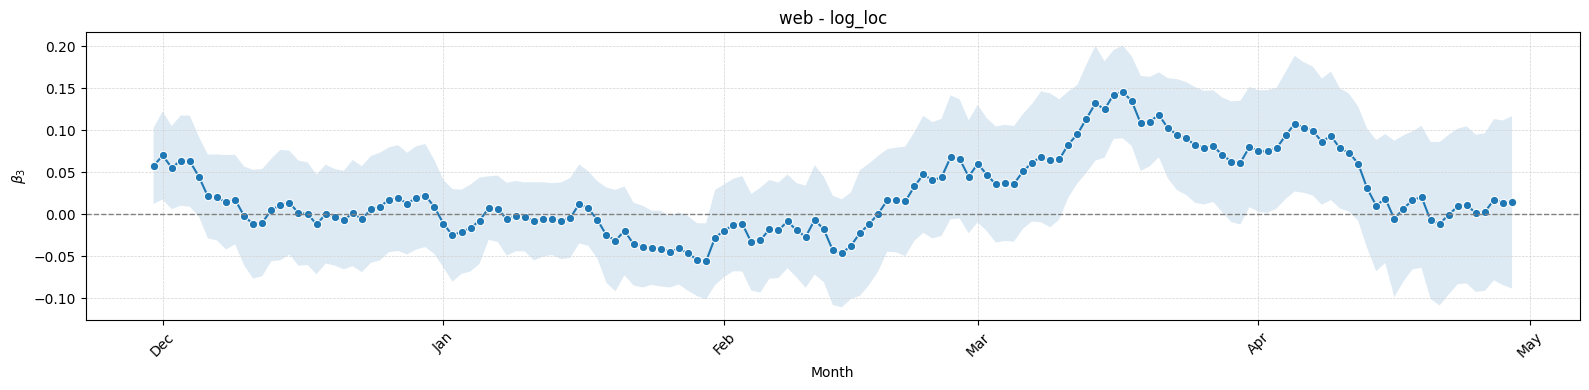

Processing: Medium


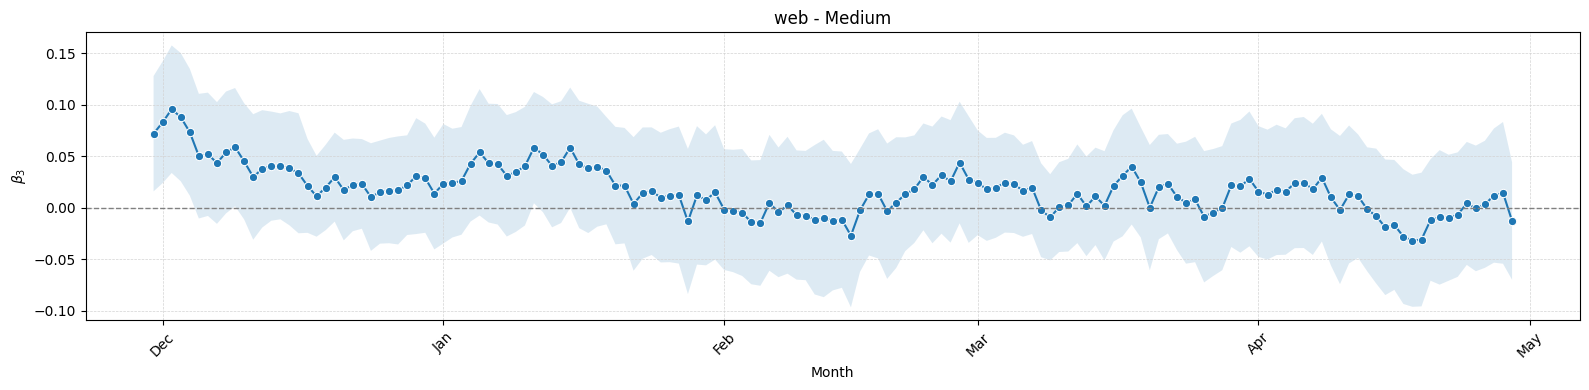

In [11]:
dfs = {'questions': questions, 'answers': answers} | tag_dfs
targets = ['log_lc', 'log_loc', 'Medium']
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc'], 'java': targets, 'python': targets, 'web': targets}
q_features = ['act_pre', 'comm_pre', 'ans_pre', 'view_pre', 'sc_pre']
a_features = ['act_pre', 'comm_pre', 'sc_pre']

for type in dfs:
    print(f'Processing: {type}')
    data = clean(dfs[type])

    pre = dfs[type][dfs[type]['P'] == 0]    

    u_pre = (pre.groupby(['OwnerUserId', 'T']).agg(
        act_pre=('PostTypeId', 'size'),
        comm_pre=('CommentCount', 'sum'),
        ans_pre=('AnswerCount', 'sum'),
        view_pre=('ViewCount', 'sum'),        
        sc_pre=('Score', 'sum')).reset_index()
    )

    if type == 'answers':
        features = a_features
    else:
        features = q_features

    # log transforms
    for c in features:
        if c == 'sc_pre':
            continue
        u_pre[f'log_{c}'] = np.log1p(u_pre[c])

    df_uf = dfs[type].merge(u_pre, on=['OwnerUserId', 'T'], how='inner')
    
    # match
    df_uf = propensity_scores(df_uf, features)

    # quantiles
    df_uf['ps_quartile'] = pd.qcut(df_uf['ps'], 4, labels=False)
    dfq1  = df_uf[df_uf['ps_quartile'] == 0]
    dfq23  = df_uf[(df_uf['ps_quartile'] == 1) | (df_uf['ps_quartile'] == 2)]
    dfq4  = df_uf[df_uf['ps_quartile'] == 3]

    groups = ['all', 'q1', 'q23', 'q4']
    dfqs = [df_uf, dfq1, dfq23, dfq4]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
    for ax, group, df_c in zip(axes, groups, dfqs):
        # activity dist
        user_counts = (df_c.groupby(['T', 'OwnerUserId']).size().reset_index(name='n_posts'))
        sns.ecdfplot(data=user_counts, x='n_posts', hue='T', ax=ax)
        ax.set_xscale('log')
        ax.set_title(f'User activity: {group}')
    plt.show()
    plt.close()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
    for ax, group, df_c in zip(axes, groups, dfqs):
        # comment count dist
        comm = (df_c.groupby(['T', 'OwnerUserId'])['CommentCount'].mean().reset_index(name='comm'))
        sns.ecdfplot(data=comm, x='comm', hue='T', ax=ax)
        ax.set_xscale('log')
        ax.set_title(f'Comment count: {group}')
    plt.show()
    plt.close()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
    for ax, group, df_c in zip(axes, groups, dfqs):
        # activity dist
        score = (df_c.groupby(['T', 'OwnerUserId'])['Score'].mean().reset_index(name='sc'))
        sns.ecdfplot(data=score, x='sc', hue='T', ax=ax)
        ax.set_xscale('log')
        ax.set_title(f'Score: {group}')
    plt.show()
    plt.close()

    if type != 'answers':
        fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
        for ax, group, df_c in zip(axes, groups, dfqs):
            # answer count dist
            ans = (df_c.groupby(['T', 'OwnerUserId'])['AnswerCount'].mean().reset_index(name='ans'))
            sns.ecdfplot(data=ans, x='ans', hue='T', ax=ax)
            ax.set_xscale('log')
            ax.set_title(f'Answer count: {group}')
        plt.show()
        plt.close()

        fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
        for ax, group, df_c in zip(axes, groups, dfqs):
            # view count dist
            view = (df_c.groupby(['T', 'OwnerUserId'])['ViewCount'].mean().reset_index(name='view'))
            sns.ecdfplot(data=view, x='view', hue='T', ax=ax)
            ax.set_xscale('log')
            ax.set_title(f'View count: {group}')
        plt.show()
        plt.close()

    for group, df_c in zip(groups, dfqs):
        print('****************************************************************')
        print(group)
        print('****************************************************************')

        # check for balance
        for x in features:
            print('Balance: --------------\n***********')
            print('Before matching: ', x, smd(df_c, x))
            print('After matching: ', x, smd(df_c, x, wcol='w_user'))

        # overlap
        print('Overlap: --------------')
        print(df_c.groupby('T')['ps'].describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))
        overlap(df_c)

        # fit
        daily = so.prepare_daily_data(df_c, outcomes[type], 'w_user')
        for outcome in outcomes[type]:
            print(f'Processing: {outcome}')
            try:
                res = regression(daily, outcome)
                so.plot_did(res, f'{type} - {outcome}', 'temp/temp.pdf')
            except Exception as e:
                print(e)